# NYC Citi Bike Time-Series Analytics

**M.Sc. Thesis Practical Work — 2021**

This notebook is a cleaned archival portfolio version of the practical analysis developed for the master's thesis:

**Improvement of Bike Sharing Disposition by Business Analytics and Open Data Usage**

The work studies 2020 NYC Citi Bike activity together with weather/relative-humidity and operational inspection data. The analysis includes exploratory business analytics, station-level demand and trip-duration analysis, stationarity testing, ACF/PACF inspection, ARIMA-family forecasting, Prophet forecasting, and data preparation for Power BI.

### Portfolio note

The analytical work and saved outputs originate from the 2021 thesis project. The notebook has been cleaned for readability without rewriting the original experiment as a modern project. Some APIs used in 2021 (for example `DataFrame.append`, legacy `statsmodels` ARIMA, and `fbprophet`) are now deprecated or renamed, so minor compatibility updates may be required to rerun every cell in a current Python environment.

The source datasets are not bundled in this notebook. They were obtained from public/open-data sources described in the thesis.

In [ ]:
import zipfile
from zipfile import ZipFile

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Data ingestion and preparation

The 2020 monthly Citi Bike trip archives are extracted, loaded, combined into seasonal groupings, converted to datetime format, and enriched with trip-duration features.

In [ ]:
#Unzipping the citibike zipped files 
with ZipFile('202001-citibike-tripdata.csv.zip', 'r') as df1:
   df1.extractall()

In [ ]:
with ZipFile('202002-citibike-tripdata.csv.zip', 'r') as df2:
   df2.extractall()

In [ ]:
with ZipFile('202003-citibike-tripdata.csv.zip', 'r') as df3:
   df3.extractall()

In [ ]:
with ZipFile('202004-citibike-tripdata.csv.zip', 'r') as df4:
   df4.extractall()

In [ ]:
with ZipFile('202005-citibike-tripdata.csv.zip', 'r') as df5:
   df5.extractall()

In [ ]:
with ZipFile('202006-citibike-tripdata.csv.zip', 'r') as df6:
   df6.extractall()

In [ ]:
with ZipFile('202007-citibike-tripdata.csv.zip', 'r') as df7:
   df7.extractall()

In [ ]:
with ZipFile('202008-citibike-tripdata.csv.zip', 'r') as df8:
   df8.extractall()

In [ ]:
with ZipFile('202009-citibike-tripdata.csv.zip', 'r') as df9:
   df9.extractall()

In [ ]:
with ZipFile('202010-citibike-tripdata.csv.zip', 'r') as df10:
   df10.extractall()

In [ ]:
with ZipFile('202011-citibike-tripdata.csv.zip', 'r') as df11:
   df11.extractall()

In [ ]:
with ZipFile('202012-citibike-tripdata.csv.zip', 'r') as df12:
   df12.extractall()

In [ ]:
#Reading the unzipped csv
df1=pd.read_csv('202001-citibike-tripdata.csv')
df2=pd.read_csv('202002-citibike-tripdata.csv')
df3=pd.read_csv('202003-citibike-tripdata.csv')
df4=pd.read_csv('202004-citibike-tripdata.csv')
df5=pd.read_csv('202005-citibike-tripdata.csv')
df6=pd.read_csv('202006-citibike-tripdata.csv')
df7=pd.read_csv('202007-citibike-tripdata.csv')
df8=pd.read_csv('202008-citibike-tripdata.csv')
df9=pd.read_csv('202009-citibike-tripdata.csv')
df10=pd.read_csv('202010-citibike-tripdata.csv')
df11=pd.read_csv('202011-citibike-tripdata.csv')
df12=pd.read_csv('202012-citibike-tripdata.csv')

In [ ]:
#Merging/Appending into meterological periods and confirming the length
Winter=df11.append(df12).append(df1)

In [ ]:
Spring = df3.append(df4).append(df5)

In [ ]:
len(df3)+len(df4)+len(df5) == len(Spring)

True

In [ ]:
Summer = df6.append(df7).append(df8)

In [ ]:
Fall = df9.append(df10).append(df11)

In [ ]:
# Converting to the object dtype in starttime and end time to datetime
df1['starttime'] = pd.to_datetime(df1['starttime'])
df1['stoptime'] = pd.to_datetime(df1['stoptime'])
df2['starttime'] = pd.to_datetime(df2['starttime'])
df2['stoptime'] = pd.to_datetime(df2['stoptime'])
df3['starttime'] = pd.to_datetime(df3['starttime'])
df3['stoptime'] = pd.to_datetime(df3['stoptime'])
df4['starttime'] = pd.to_datetime(df4['starttime'])
df4['stoptime'] = pd.to_datetime(df4['stoptime'])
df5['starttime'] = pd.to_datetime(df5['starttime'])
df5['stoptime'] = pd.to_datetime(df5['stoptime'])
df6['starttime'] = pd.to_datetime(df6['starttime'])
df6['stoptime'] = pd.to_datetime(df6['stoptime'])
df7['starttime'] = pd.to_datetime(df7['starttime'])
df7['stoptime'] = pd.to_datetime(df7['stoptime'])
df8['starttime'] = pd.to_datetime(df8['starttime'])
df8['stoptime'] = pd.to_datetime(df8['stoptime'])
df9['starttime'] = pd.to_datetime(df9['starttime'])
df9['stoptime'] = pd.to_datetime(df9['stoptime'])
df10['starttime'] = pd.to_datetime(df10['starttime'])
df10['stoptime'] = pd.to_datetime(df10['stoptime'])
df11['starttime'] = pd.to_datetime(df11['starttime'])
df11['stoptime'] = pd.to_datetime(df11['stoptime'])
df12['starttime'] = pd.to_datetime(df12['starttime'])
df12['stoptime'] = pd.to_datetime(df12['stoptime'])
# Winter['starttime'] = pd.to_datetime(Winter['starttime'])
# Winter['stoptime'] = pd.to_datetime(Winter['stoptime'])
# Summer['starttime'] = pd.to_datetime(Summer['starttime'])
# Summer['stoptime'] = pd.to_datetime(Summer['stoptime'])
# Spring['starttime'] = pd.to_datetime(Spring['starttime'])
# Spring['stoptime'] = pd.to_datetime(Spring['stoptime'])
# Fall['starttime'] = pd.to_datetime(Fall['starttime'])
# Fall['stoptime'] = pd.to_datetime(Fall['stoptime'])

In [ ]:
#Having the tripduration in minutes
df1['tripminutes'] = df1.tripduration/60
df2['tripminutes'] = df2.tripduration/60
df3['tripminutes'] = df3.tripduration/60
df4['tripminutes'] = df4.tripduration/60
df5['tripminutes'] = df5.tripduration/60
df6['tripminutes'] = df6.tripduration/60
df7['tripminutes'] = df7.tripduration/60
df8['tripminutes'] = df8.tripduration/60
df9['tripminutes'] = df9.tripduration/60
df10['tripminutes'] = df10.tripduration/60
df11['tripminutes'] = df11.tripduration/60
df12['tripminutes'] = df12.tripduration/60
# Winter['tripminutes'] = Winter.tripduration/60
# Summer['tripminutes'] = Summer.tripduration/60
# Spring['tripminutes'] = Spring.tripduration/60
# Fall['tripminutes'] = Fall.tripduration/60

## 2. Seasonal ridership and descriptive analysis

This section examines trip duration, rider type, gender distribution, and hour-of-day usage patterns across meteorological seasons.

In [ ]:
# Total duration
totalWinterusage = Winter['tripminutes'].sum()
print(totalWinterusage)

67912030.98333338


In [ ]:
totalSummerusage = Summer['tripminutes'].sum()
print(totalSummerusage)

161475390.49999997


In [ ]:
totalSpringusage = Spring['tripminutes'].sum()
print(totalSpringusage)

79495326.88333338


In [ ]:
totalFallusage = Fall['tripminutes'].sum()
print(totalFallusage)

135459525.00000003


In [ ]:
#Counting the Usertype
Winter.usertype.value_counts()

Subscriber    3428844
Customer       637385
Name: usertype, dtype: int64

In [ ]:
Summer.usertype.value_counts()

Subscriber    4509584
Customer      1808011
Name: usertype, dtype: int64

In [ ]:
Spring.usertype.value_counts()

Subscriber    2442622
Customer       796487
Name: usertype, dtype: int64

In [ ]:
Fall.usertype.value_counts()

Subscriber    4882197
Customer      1591601
Name: usertype, dtype: int64

In [ ]:
#Counting the Gender per season
Winter.gender.value_counts()

1    2666152
2    1066721
0     333356
Name: gender, dtype: int64

In [ ]:
Summer.gender.value_counts()

1    3575258
2    1910540
0     831797
Name: gender, dtype: int64

In [ ]:
Spring.gender.value_counts()

1    1952696
2     916254
0     370159
Name: gender, dtype: int64

In [ ]:
Fall.gender.value_counts()

1    3829080
2    1898280
0     746438
Name: gender, dtype: int64

In [ ]:
Winter['Winter_2020'] = Winter.starttime.dt.hour

In [ ]:
wnames_list = Winter.Winter_2020.value_counts().sort_index().index.values
wvalues_list = Winter.Winter_2020.value_counts().sort_index().values

[(0.0, 700000.0)]

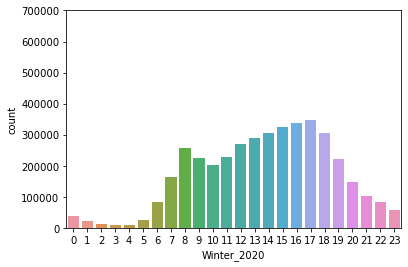

In [ ]:
#sns.countplot(x='Winter_2020', data=Winter)

ax = sns.countplot(x='Winter_2020', data=Winter)
ax.set(ylim=(0, 700000))

In [ ]:
Summer['Summer_2020'] = Summer.starttime.dt.hour

[(0.0, 700000.0)]

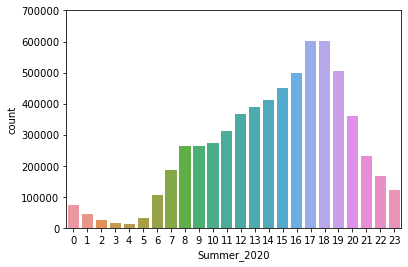

In [ ]:
ax = sns.countplot(x='Summer_2020', data=Summer)
ax.set(ylim=(0, 700000))

In [ ]:
Spring['Spring_2020'] = Spring.starttime.dt.hour

[(0.0, 700000.0)]

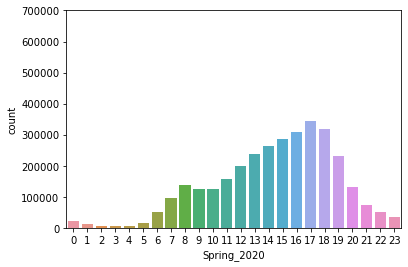

In [ ]:
ax = sns.countplot(x='Spring_2020', data=Spring)
ax.set(ylim=(0, 700000))

In [ ]:
Fall['Fall_2020'] = Fall.starttime.dt.hour

[(0.0, 700000.0)]

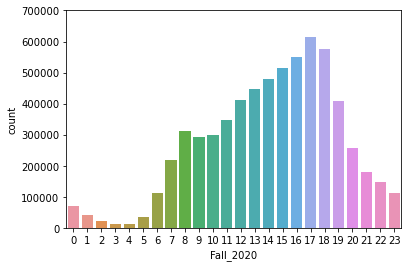

In [ ]:
ax = sns.countplot(x='Fall_2020', data=Fall)
ax.set(ylim=(0, 700000))

In [ ]:
#pd.set_option('display.max_rows', df.shape[0]+1)

## 3. Station-level usage analysis

Monthly station activity is explored to identify highly and lightly patronized stations and stations associated with large aggregate trip durations.

In [ ]:
#CONDITIONAL SELECTIONS
#Most revenue generated stations
#For January
maxdf1=df1.groupby('start station name').sum('tripminutes')
maxdf1

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
1 Ave & E 110 St,502601,2408744,28105.913441,-50943.488700,2209776,28101.402308,-50952.052550,23448763,1365623,852,8376.683333
1 Ave & E 16 St,3101403,2436840,196940.276593,-357701.304681,5283650,196964.358299,-357717.890985,156025273,9584388,5819,51690.050000
1 Ave & E 18 St,2795004,8943395,181876.471437,-330323.129895,4897077,181897.063661,-330346.868789,145105905,8855131,5538,46583.400000
1 Ave & E 30 St,2165464,1534568,116642.753800,-211791.458028,3089922,116651.161983,-211811.536175,95020133,5668613,3374,36091.066667
1 Ave & E 44 St,2265061,1140685,102160.299789,-185440.415896,4785810,102178.532472,-185447.678905,82376591,4955656,2963,37751.016667
1 Ave & E 5 St,2551491,8592480,93465.857880,-169798.762755,2547439,93477.180777,-169805.805512,75227776,4545395,2735,42524.850000
1 Ave & E 62 St,2539891,10170654,131944.093094,-239411.563492,7166937,131944.057538,-239428.583249,107398117,6410557,3733,42331.516667
1 Ave & E 68 St,3717594,14071680,182627.223520,-331332.668397,9839106,182618.939959,-331379.059072,147338104,8868496,5477,61959.900000
1 Ave & E 78 St,2125584,9611540,124801.268440,-226371.714313,7846517,124791.653235,-226404.145169,98846394,6065127,3747,35426.400000


In [ ]:
pd.set_option('display.max_rows', maxdf1.shape[0]+1)

In [ ]:
#For January
maxdf1[maxdf1.tripminutes == maxdf1.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
Pershing Square North,9020154,5570946,437430.604782,-794076.696204,12378009,437358.044827,-794175.265178,352277318,21219480,11580,150335.9


In [ ]:
#Most revenue generated stations
#For Febbruary
maxdf2=df2.groupby('start station name').sum('tripminutes')
maxdf2

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
1 Ave & E 110 St,436016,2171016,25332.035191,-45915.684300,2038483,25329.502134,-45922.546854,21194660,1229960,738,7266.933333
1 Ave & E 16 St,2647000,2211552,178732.974910,-324631.504641,4975997,178754.331416,-324648.490573,142855178,8698197,5198,44116.666667
1 Ave & E 18 St,2622783,8250357,167782.572419,-304725.861599,4619849,167799.402125,-304748.583426,135125795,8166329,5064,43713.050000
1 Ave & E 30 St,1798372,1382880,105112.923741,-190856.429555,2855372,105119.344484,-190873.743195,85244297,5108779,3028,29972.866667
1 Ave & E 44 St,2094762,1047410,93806.545718,-170276.760029,4250775,93820.934090,-170284.508145,75188521,4550659,2692,34912.700000
1 Ave & E 5 St,1539722,8921952,97049.733912,-176309.564987,2847427,97060.251955,-176315.824981,78156891,4721213,2821,25662.033333
1 Ave & E 62 St,2209641,8517962,110503.687481,-200508.108936,6160734,110503.368052,-200520.345885,89733126,5369225,3173,36827.350000
1 Ave & E 68 St,3268461,12202785,158372.045396,-287327.548375,8552942,158363.460074,-287368.411663,129796333,7691070,4799,54474.350000
1 Ave & E 78 St,1948358,9127980,118522.470780,-214982.872240,7607645,118512.756957,-215013.284725,94066848,5761310,3563,32472.633333


In [ ]:
#For Febraury
maxdf2[maxdf2.tripminutes == maxdf2.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
Pershing Square North,7551388,4874967,382782.343089,-694872.592458,11116469,382725.926867,-694955.493246,307634940,18571598,10211,125856.466667


In [ ]:
#Most revenue generated stations
#For March
maxdf3=df3.groupby('start station name').sum('tripminutes')
maxdf3[maxdf3.tripminutes == maxdf3.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
Pershing Square North,9115602,3466401,272181.760021,-494097.096962,8541828,272141.687367,-494151.714955,220045789,13201662,7255,151926.7


In [ ]:
#Most revenue generated stations
#For April
maxdf4=df4.groupby('start station name').sum('tripminutes')
maxdf4[maxdf4.tripminutes == maxdf4.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
West Drive & Prospect Park West,7635885,8725227,103645.050535,-188573.624551,7973197,103674.329631,-188566.037962,86287941,5043870,2617,127264.75


In [ ]:
#Most revenue generated stations
#For May
maxdf5=df5.groupby('start station name').sum('tripminutes')
maxdf5[maxdf5.tripminutes == maxdf5.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
12 Ave & W 125 St,18928878,27291192,287034.278568,-520089.56796,20815426,286860.290531,-520162.007996,237760046,13931702,8041,315481.3


In [ ]:
#Most revenue generated stations
#For June
maxdf6=df6.groupby('start station name').sum('tripminutes')
maxdf6[maxdf6.tripminutes == maxdf6.tripminutes.max()]

In [ ]:
#Most revenue generated stations
#For July
maxdf7=df7.groupby('start station name').sum('tripminutes')
maxdf7[maxdf7.tripminutes == maxdf7.tripminutes.max()]

In [ ]:
#Most revenue generated stations
#For August
maxdf8=df8.groupby('start station name').sum('tripminutes')
maxdf8[maxdf8.tripminutes == maxdf8.tripminutes.max()]

In [ ]:
#Most revenue generated stations
#For September
maxdf9=df9.groupby('start station name').sum('tripminutes')
maxdf9[maxdf9.tripminutes == maxdf9.tripminutes.max()]

In [ ]:
#Most revenue generated stations
#For October
maxdf10=df10.groupby('start station name').sum('tripminutes')
maxdf10[maxdf10.tripminutes == maxdf10.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
12 Ave & W 40 St,16725269,4798190,380502.768312,-690815.920308,16317491,380386.617997,-690732.142817,347870650,18488971,11377,278754.483333


In [ ]:
#Most revenue generated stations
#For November
maxdf11=df11.groupby('start station name').sum('tripminutes')
maxdf11[maxdf11.tripminutes == maxdf11.tripminutes.max()]

In [ ]:
#Most revenue generated stations
#For December
maxdf12=df12.groupby('start station name').sum('tripminutes')
maxdf12[maxdf12.tripminutes == maxdf12.tripminutes.max()]

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,birth year,gender,tripminutes
start station name,,,,,,,,,,,
1 Ave & E 68 St,6575414,22634046,293752.627831,-532942.680462,18229206,293744.758008,-532995.842557,301157259,14276849,9512,109590.233333


In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#January
df1[df1.tripminutes == df1.tripminutes.max()]

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,tripminutes
108613,1952746,2020-01-04 15:46:46.928,2020-01-27 06:12:33.237,146,Hudson St & Reade St,40.71625,-74.009106,3529,Lenox Ave & W 130 St,40.810792,-73.943068,34062,Subscriber,1971,1,32545.766667


In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#February
df2[df2.tripminutes == df2.tripminutes.max()]

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,tripminutes
86664,3318587,2020-02-03 13:54:31.330,2020-03-13 00:44:19.062,3087,Metropolitan Ave & Meeker Ave,40.714133,-73.952344,3775,Suydam St & Knickerbocker Ave,40.702013,-73.923769,32497,Customer,1993,2,55309.783333


In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#March
df3[df3.tripminutes == df3.tripminutes.max()]

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,tripminutes
426602,3247190,2020-03-09 18:14:18.713,2020-04-16 08:14:08.873,519,Pershing Square North,40.751873,-73.977706,3379,E 103 St & Lexington Ave,40.790305,-73.947558,41678,Customer,1984,2,54119.833333


In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#April
df4[df4.tripminutes == df4.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#May
df5[df5.tripminutes == df5.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#June
df6[df6.tripminutes == df6.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#July
df7[df7.tripminutes == df7.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#August
df8[df8.tripminutes == df8.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#September
df9[df9.tripminutes == df9.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#October
df10[df10.tripminutes == df10.tripminutes.max()]

In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#November
df11[df11.tripminutes == df11.tripminutes.max()]

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,tripminutes
59629,2422830,2020-11-02 15:18:02.563,2020-11-30 16:18:32.686,4201,Clay Ave & Claremont Pkwy,40.83999,-73.90549,4050,W 159 St & Edgecombe Ave,40.833303,-73.939326,47617,Customer,1990,1,40380.5


In [ ]:
#A Rider with maximum minutes per trip (Monthly)
#December
df12[df12.tripminutes == df12.tripminutes.max()]

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,tripminutes
181687,2687593,2020-12-04 15:43:41.246,2021-01-04 18:16:54.769,173,Broadway & W 49 St,40.760683,-73.984527,267,Broadway & W 36 St,40.750977,-73.987654,40798,Customer,1998,2,44793.216667


## 4. Daily demand and weather integration

Trip records are aggregated by date and station, then combined with relative-humidity data to study daily demand, usage duration, and weather relationships.

In [ ]:
#Setting date to only Year, Month and Day
df1['Date'] = df1['starttime'].dt.strftime('%Y-%m-%d')
df2['Date'] = df2['starttime'].dt.strftime('%Y-%m-%d')
df3['Date'] = df3['starttime'].dt.strftime('%Y-%m-%d')
df4['Date'] = df4['starttime'].dt.strftime('%Y-%m-%d')
df5['Date'] = df5['starttime'].dt.strftime('%Y-%m-%d')
df6['Date'] = df6['starttime'].dt.strftime('%Y-%m-%d')
df7['Date'] = df7['starttime'].dt.strftime('%Y-%m-%d')
df8['Date'] = df8['starttime'].dt.strftime('%Y-%m-%d')
df9['Date'] = df9['starttime'].dt.strftime('%Y-%m-%d')
df10['Date'] = df10['starttime'].dt.strftime('%Y-%m-%d')
df11['Date'] = df11['starttime'].dt.strftime('%Y-%m-%d')
df12['Date'] = df12['starttime'].dt.strftime('%Y-%m-%d')

In [ ]:
#Converting Date to Datetime
df1['Date'] = pd.to_datetime(df1['Date'])
df2['Date'] = pd.to_datetime(df2['Date'])
df3['Date'] = pd.to_datetime(df3['Date'])
df4['Date'] = pd.to_datetime(df4['Date'])
df5['Date'] = pd.to_datetime(df5['Date'])
df6['Date'] = pd.to_datetime(df6['Date'])
df7['Date'] = pd.to_datetime(df7['Date'])
df8['Date'] = pd.to_datetime(df8['Date'])
df9['Date'] = pd.to_datetime(df9['Date'])
df10['Date'] = pd.to_datetime(df10['Date'])
df11['Date'] = pd.to_datetime(df11['Date'])
df12['Date'] = pd.to_datetime(df12['Date'])

In [ ]:
pdf1=df1[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf2=df2[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf3=df3[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf4=df4[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf5=df5[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf6=df6[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf7=df7[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf8=df8[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf9=df9[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf10=df10[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf11=df11[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]
pdf12=df12[['Date','start station name', 'start station latitude', 'start station longitude', 'tripminutes']]

In [ ]:
#Based on rental
cpdf1= pdf1.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf2= pdf2.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf3= pdf3.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf4= pdf4.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf5= pdf5.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf6= pdf6.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf7= pdf7.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf8= pdf8.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf9= pdf9.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf10= pdf10.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf11= pdf11.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()
cpdf12= pdf12.groupby(['Date', 'start station latitude', 'start station longitude'])['start station name'].value_counts().to_frame(name = 'mtrip').reset_index()

In [ ]:
cpd1=cpdf1[['Date','mtrip']]
cpd2=cpdf2[['Date','mtrip']]
cpd3=cpdf3[['Date','mtrip']]
cpd4=cpdf4[['Date','mtrip']]
cpd5=cpdf5[['Date','mtrip']]
cpd6=cpdf6[['Date','mtrip']]
cpd7=cpdf7[['Date','mtrip']]
cpd8=cpdf8[['Date','mtrip']]
cpd9=cpdf9[['Date','mtrip']]
cpd10=cpdf10[['Date','mtrip']]
cpd11=cpdf11[['Date','mtrip']]
cpd12=cpdf12[['Date','mtrip']]

In [ ]:
cpd1= cpd1.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd2= cpd2.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd3= cpd3.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd4= cpd4.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd5= cpd5.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd6= cpd6.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd7= cpd7.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd8= cpd8.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd9= cpd9.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd10= cpd10.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd11= cpd11.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()
cpd12= cpd12.groupby(['Date'])['mtrip'].sum().to_frame(name = 'demand').reset_index()

In [ ]:
cpd =cpd1.append(cpd2).append(cpd3).append(cpd4).append(cpd5).append(cpd6).append(cpd7).append(cpd8).append(cpd9).append(cpd10).append(cpd11).append(cpd12)

In [ ]:
#LEFT JOIN
cdff1 = pd.merge(cpd1,Jan, how ='left', left_on=['Date'], right_on=['Date'])
cdff2 = pd.merge(cpd2,Feb, how ='left', left_on=['Date'], right_on=['Date'])
cdff3 = pd.merge(cpd3,March, how ='left', left_on=['Date'], right_on=['Date'])
cdff4 = pd.merge(cpd4,April, how ='left', left_on=['Date'], right_on=['Date'])
cdff5 = pd.merge(cpd5,May, how ='left', left_on=['Date'], right_on=['Date'])
cdff6 = pd.merge(cpd6,June, how ='left', left_on=['Date'], right_on=['Date'])
cdff7 = pd.merge(cpd7,July, how ='left', left_on=['Date'], right_on=['Date'])
cdff8 = pd.merge(cpd8,August, how ='left', left_on=['Date'], right_on=['Date'])
cdff9 = pd.merge(cpd9,Sept, how ='left', left_on=['Date'], right_on=['Date'])
cdff10 = pd.merge(cpd10,Oct, how ='left', left_on=['Date'], right_on=['Date'])
cdff11 = pd.merge(cpd11,Nov, how ='left', left_on=['Date'], right_on=['Date'])
cdff12 = pd.merge(cpd12,Dec, how ='left', left_on=['Date'], right_on=['Date'])

In [ ]:
cdff1['humavgP'] = Jan['humavgP']
cdff2['humavgP'] = Feb['humavgP'] 
cdff3['humavgP'] = March['humavgP'] 
cdff4['humavgP'] = April['humavgP'] 
cdff5['humavgP'] = May['humavgP'] 
cdff6['humavgP'] = June['humavgP'] 
cdff7['humavgP'] = July['humavgP'] 
cdff8['humavgP'] = August['humavgP'] 
cdff9['humavgP'] = Sept['humavgP'] 
cdff10['humavgP'] = Oct['humavgP'] 
cdff11['humavgP'] = Nov['humavgP'] 
cdff12['humavgP'] = Dec['humavgP']

In [ ]:
cdff1['dtriprate'] = cdff1.demand/1000
cdff2['dtriprate'] = cdff2.demand/1000
cdff3['dtriprate'] = cdff3.demand/1000
cdff4['dtriprate'] = cdff4.demand/1000
cdff5['dtriprate'] = cdff5.demand/1000
cdff6['dtriprate'] = cdff6.demand/1000
cdff7['dtriprate'] = cdff7.demand/1000
cdff8['dtriprate'] = cdff8.demand/1000
cdff9['dtriprate'] = cdff9.demand/1000
cdff10['dtriprate'] = cdff10.demand/1000
cdff11['dtriprate'] = cdff11.demand/1000
cdff12['dtriprate'] = cdff12.demand/1000

In [ ]:
cplt1=cdff1[['Date','humavgP','dtriprate']]
cplt2=cdff2[['Date','humavgP','dtriprate']]
cplt3=cdff3[['Date','humavgP','dtriprate']]
cplt4=cdff4[['Date','humavgP','dtriprate']]
cplt5=cdff5[['Date','humavgP','dtriprate']]
cplt6=cdff6[['Date','humavgP','dtriprate']]
cplt7=cdff7[['Date','humavgP','dtriprate']]
cplt8=cdff8[['Date','humavgP','dtriprate']]
cplt9=cdff9[['Date','humavgP','dtriprate']]
cplt10=cdff10[['Date','humavgP','dtriprate']]
cplt11=cdff11[['Date','humavgP','dtriprate']]
cplt12=cdff12[['Date','humavgP','dtriprate']]

(0.0, 150.0)

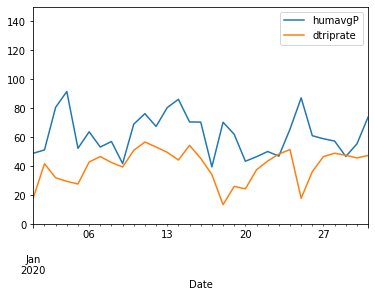

In [ ]:
cplt1.set_index("Date", inplace=True)
cplt1.plot()
plt.ylim(0,150)

(0.0, 150.0)

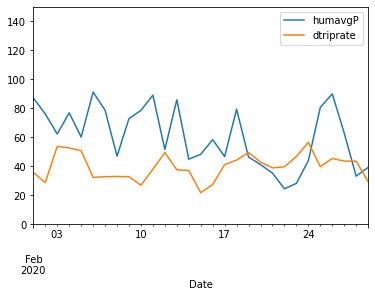

In [ ]:
cplt2.set_index("Date", inplace=True)
cplt2.plot()
plt.ylim(0,150)

(0.0, 150.0)

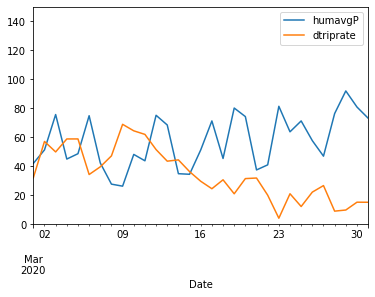

In [ ]:
cplt3.set_index("Date", inplace=True)
cplt3.plot()
plt.ylim(0,150)

(0.0, 150.0)

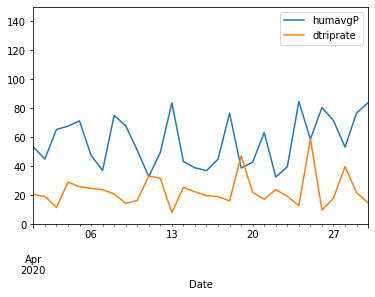

In [ ]:
cplt4.set_index("Date", inplace=True)
cplt4.plot()
plt.ylim(0,150)

(0.0, 150.0)

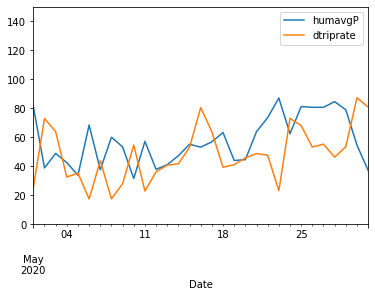

In [ ]:
cplt5.set_index("Date", inplace=True)
cplt5.plot()
plt.ylim(0,150)

(0.0, 150.0)

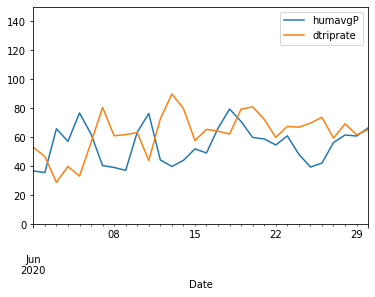

In [ ]:
cplt6.set_index("Date", inplace=True)
cplt6.plot()
plt.ylim(0,150)

(0.0, 150.0)

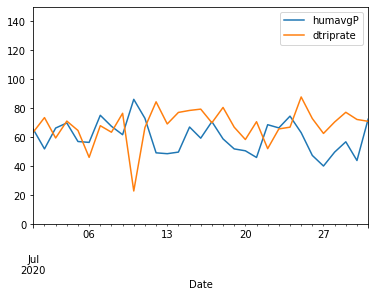

In [ ]:
cplt7.set_index("Date", inplace=True)
cplt7.plot()
plt.ylim(0,150)

(0.0, 150.0)

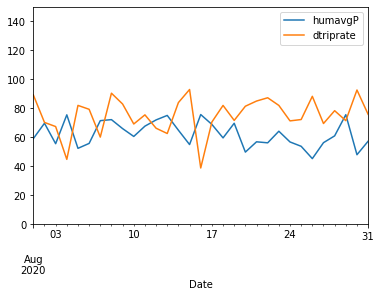

In [ ]:
cplt8.set_index("Date", inplace=True)
cplt8.plot()
plt.ylim(0,150)

(0.0, 150.0)

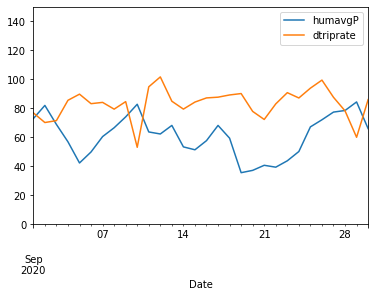

In [ ]:
cplt9.set_index("Date", inplace=True)
cplt9.plot()
plt.ylim(0,150)

(0.0, 150.0)

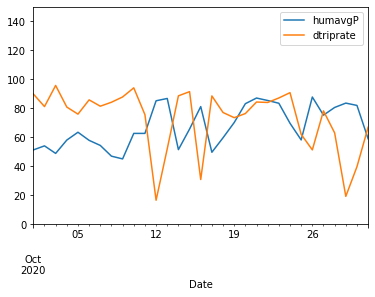

In [ ]:
cplt10.set_index("Date", inplace=True)
cplt10.plot()
plt.ylim(0,150)

(0.0, 150.0)

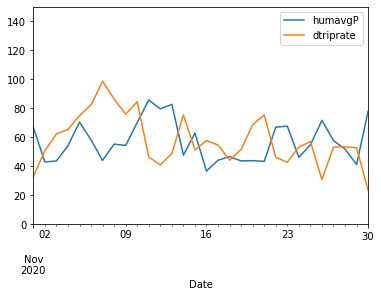

In [ ]:
cplt11.set_index("Date", inplace=True)
cplt11.plot()
plt.ylim(0,150)

(0.0, 150.0)

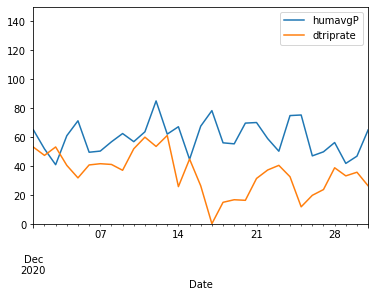

In [ ]:
cplt12.set_index("Date", inplace=True)
cplt12.plot()
plt.ylim(0,150)

In [ ]:
Jan_Decdf=cdff1.append(cdff2).append(cdff3).append(cdff4).append(cdff5).append(cdff6).append(cdff7).append(cdff8).append(cdff9).append(cdff10).append(cdff11).append(cdff12)

In [ ]:
Jan_Decdf[["humavgP", "dtriprate"]].corr()

,humavgP,dtriprate
humavgP,1.000000,-0.134455
dtriprate,-0.134455,1.000000


In [ ]:
Jan_Decdf[["humavgP", "dtriprate"]].cov()

,humavgP,dtriprate
humavgP,222.214941,-47.043132
dtriprate,-47.043132,550.894368


## 5. Demand features for business intelligence

Station-level demand and weather variables are prepared for downstream dashboard and Power BI analysis.

In [ ]:
#Preparing bike demand data for export 
cpr1 = pd.merge(cpdf1,rh1, how ='left', left_on=['Date'], right_on=['Date'])
cpr2 = pd.merge(cpdf2,rh2, how ='left', left_on=['Date'], right_on=['Date'])
cpr3 = pd.merge(cpdf3,rh3, how ='left', left_on=['Date'], right_on=['Date'])
cpr4 = pd.merge(cpdf4,rh4, how ='left', left_on=['Date'], right_on=['Date'])
cpr5 = pd.merge(cpdf5,rh5, how ='left', left_on=['Date'], right_on=['Date'])
cpr6 = pd.merge(cpdf6,rh6, how ='left', left_on=['Date'], right_on=['Date'])
cpr7 = pd.merge(cpdf7,rh7, how ='left', left_on=['Date'], right_on=['Date'])
cpr8 = pd.merge(cpdf8,rh8, how ='left', left_on=['Date'], right_on=['Date'])
cpr9 = pd.merge(cpdf9,rh9, how ='left', left_on=['Date'], right_on=['Date'])
cpr10 = pd.merge(cpdf10,rh10, how ='left', left_on=['Date'], right_on=['Date'])
cpr11 = pd.merge(cpdf11,rh11, how ='left', left_on=['Date'], right_on=['Date'])
cpr12 = pd.merge(cpdf12,rh12, how ='left', left_on=['Date'], right_on=['Date'])

In [ ]:
cprd =cpr1.append(cpr2).append(cpr3).append(cpr4).append(cpr5).append(cpr6).append(cpr7).append(cpr8).append(cpr9).append(cpr10).append(cpr11).append(cpr12)

In [ ]:
cprd.rename(columns = {"start station latitude":"latitude", "start station longitude":"longitude", "start station name":"start_station_name", "mtrip": "trip_demand"}, inplace="True")

In [ ]:
cpbi = cprd

In [ ]:
cpbi['Month'] = cpbi['Date'].dt.strftime('%b-%Y')

In [ ]:
cpbi.to_csv('Nafiu for Citibike Demand PowerBI', sep='\t')

In [ ]:
cpr=cprd[['Date','start_station_name', 'trip_demand','humavgP']]

In [ ]:
X_train = cpd[cpd['Date'] < '2020-11-14']
X_valid = cpd[cpd['Date'] >= '2020-11-14']

print('X_train shape', X_train.shape)
print('X_valid shape', X_valid.shape)

X_train['Date'].unique()

X_train shape (318, 2)
X_valid shape (48, 2)


array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000',
       '2020-01-11T00:00:00.000000000', '2020-01-12T00:00:00.000000000',
       '2020-01-13T00:00:00.000000000', '2020-01-14T00:00:00.000000000',
       '2020-01-15T00:00:00.000000000', '2020-01-16T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-19T00:00:00.000000000', '2020-01-20T00:00:00.000000000',
       '2020-01-21T00:00:00.000000000', '2020-01-22T00:00:00.000000000',
       '2020-01-23T00:00:00.000000000', '2020-01-24T00:00:00.000000000',
       '2020-01-25T00:00:00.000000000', '2020-01-26T00:00:00.000000000',
       '2020-01-27T00:00:00.000000000', '2020-01-28

In [ ]:
#Splitting data 
#train data
#station = X_train[X_train['start_station_name'] == '1 Ave & E 68 St']
station2 = X_train[['Date', 'demand']]
#TESTING STATIONS:1 Ave & E 30 St, Pershing Square North, 1 Ave & E 68 St
#valid data
#station_va = X_valid[X_valid['start_station_name'] == '1 Ave & E 68 St']
station_va2 = X_valid[['Date', 'demand']]

#Set index
station2.set_index('Date', inplace=True)
station_va2.set_index('Date', inplace=True)

#Setting index for 48 days
index_48_days = pd.date_range(station2.index[-1], freq='D', periods = 48)

index_48_days

DatetimeIndex(['2020-11-13', '2020-11-14', '2020-11-15', '2020-11-16',
               '2020-11-17', '2020-11-18', '2020-11-19', '2020-11-20',
               '2020-11-21', '2020-11-22', '2020-11-23', '2020-11-24',
               '2020-11-25', '2020-11-26', '2020-11-27', '2020-11-28',
               '2020-11-29', '2020-11-30', '2020-12-01', '2020-12-02',
               '2020-12-03', '2020-12-04', '2020-12-05', '2020-12-06',
               '2020-12-07', '2020-12-08', '2020-12-09', '2020-12-10',
               '2020-12-11', '2020-12-12', '2020-12-13', '2020-12-14',
               '2020-12-15', '2020-12-16', '2020-12-17', '2020-12-18',
               '2020-12-19', '2020-12-20', '2020-12-21', '2020-12-22',
               '2020-12-23', '2020-12-24', '2020-12-25', '2020-12-26',
               '2020-12-27', '2020-12-28', '2020-12-29', '2020-12-30'],
              dtype='datetime64[ns]', freq='D')

24868.839710913875

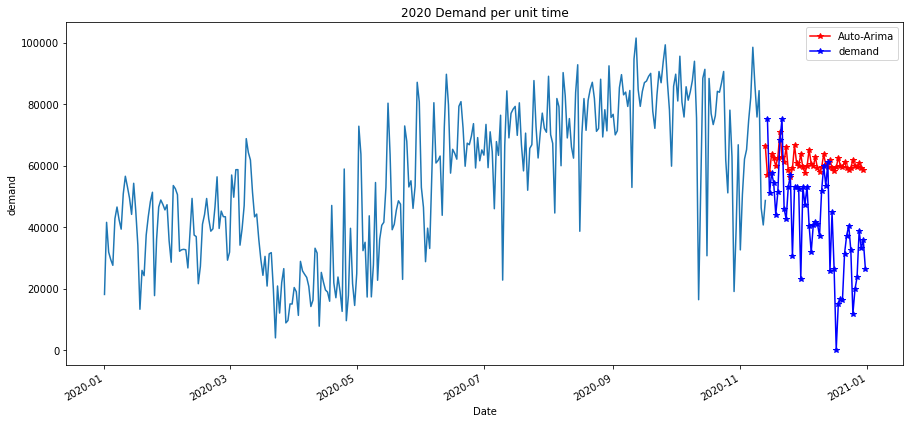

In [ ]:
#AUTO ARIMA
auto_arima_model = pm.auto_arima(station2, seasonal=True, m=7)

#m=7 for daily, 12 for monthly, 52 for weekly data

predict2 = auto_arima_model.predict(48)
predict2 = pd.Series(predict2, index=index_48_days)
predict2 = predict2.rename("Auto-Arima")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='demand', data=station2)
chart.set_title('2020 Demand per unit time')
predict2.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

AUTOARIMAMSE = np.square(np.subtract(predict2.values, station_va2['demand'].values)).mean()
np.sqrt(AUTOARIMAMSE)

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


44256.25002533318

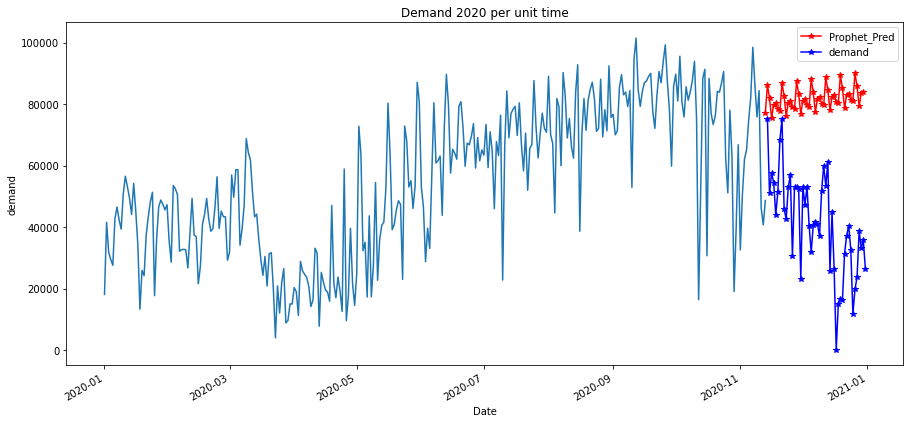

In [ ]:
station3 = X_train.copy()
#station3 = station3.reset_index(drop=False, inplace=True)
station3 = station3[['Date', 'demand']]
station3.columns = ['ds', 'y']
station3['ds'] = to_datetime(station3['ds'])

#Model
model = Prophet()
#fitting
prophet_model = model.fit(station3)

#define the prediction period
df_index_48_days = pd.DataFrame(index_48_days)
df_index_48_days.columns = ['ds']
df_index_48_days['ds'] = to_datetime(df_index_48_days['ds'])

#prediction
predict3 = prophet_model.predict(df_index_48_days)
predict3 = pd.Series(predict3['yhat'].values, index=index_48_days)
predict3 = predict3.rename("Prophet_Pred")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='demand', data=station2)
chart.set_title('Demand 2020 per unit time')
predict3.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ProphetMSE = np.square(np.subtract(predict3.values, station_va2['demand'].values)).mean()
np.sqrt(ProphetMSE)

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


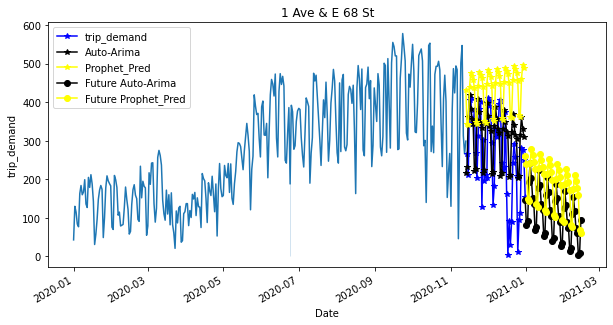

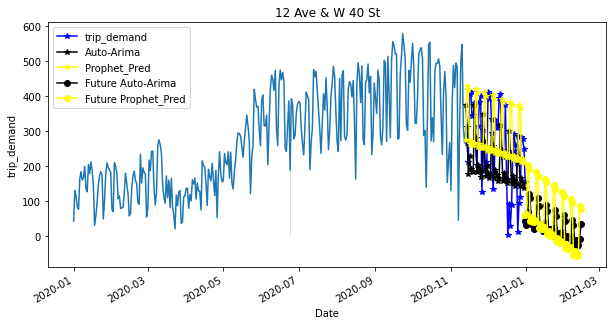

In [ ]:
stations = cpr['start_station_name'].unique()

Stations = ['1 Ave & E 68 St','12 Ave & W 40 St'] 
#Stations = ['Metropolitan Ave & Meeker Ave'] 

for c in Stations:
    #filter train data
    train_data = X_train[X_train['start_station_name'] == c]
    train_data2 = train_data[['Date', 'trip_demand']]
    
    #filter valid data
    valid_data = X_valid[X_valid['start_station_name'] == c]
    valid_data2 = valid_data[['Date', 'trip_demand']]
    
    #all the data from the beginning
    all_data = cpr[cpr['start_station_name'] == c]
    all_data2 = all_data[['Date', 'trip_demand']]
    
    #convert to datetime
    train_data2.set_index('Date', inplace=True)
    valid_data2.set_index('Date', inplace=True)
    valid_data2.columns = ['Validated Data']
    all_data2.set_index('Date', inplace=True)
    
    #setting the validation days
    index_48_days = pd.date_range(train_data2.index[-1], freq='D', periods = 48)
    
    #Setting the future days
    future_index_46_days = pd.date_range(valid_data2.index[-1], freq='D', periods = 46)
    
    try:
#         del t_predict1
        del t_predict2
        del t_predict3
        
#         del f_predict1
        del f_predict2
        del f_predict3
        
    except:
        print("")
        
#     try:
#         del df_predict1
#         del df_predict2
#     except:
#         print("")
        
#     #VALID ARIMA
#     try:
#         try:
#             model_arima = ARIMA(train_data2, order=(4,1,3))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             t_predict1 = model_arima_fit.forecast(48)[0]

#             #Passing the same index as others
#             t_predict1 = pd.Series(t_predict1, index=index_48_days)
#             t_predict1 = t_predict1.rename("ARIMA")
#         except:
#             model_arima = ARIMA(train_data2, order=(4,1,4))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             t_predict1 = model_arima_fit.forecast(48)[0]

#             #Passing the same index as others
#             t_predict1 = pd.Series(t_predict1, index=index_48_days)
#             t_predict1 = t_predict1.rename("ARIMA")
#     except:
#         print(c, 'Arima Error')
        
#     #FUTURE ARIMA
#     try:
#         try:
#             model_arima = ARIMA(all_data2, order=(4,1,3))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             f_predict1 = model_arima_fit.forecast(46)[0]

#             #Passing the same index as others
#             f_predict1 = pd.Series(f_predict1, index=future_index_46_days)
#             f_predict1 = f_predict1.rename("Future ARIMA")
#         except:
#             model_arima = ARIMA(all_data2, order=(4,1,4))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             f_predict1 = model_arima_fit.forecast(46)[0]

#             #Passing the same index as others
#             f_predict1 = pd.Series(f_predict1, future_index_46_days)
#             f_predict1 = f_predict1.rename("Future ARIMA")
#     except:
#         print(c, 'Arima Future Error')
    
    #AUTO ARIMA VALIDATED
    try:
        auto_arima_model = pm.auto_arima(train_data2, seasonal=True, m=7)

        #m=7 for daily, 12 for monthly, 52 for weekly data

        t_predict2 = auto_arima_model.predict(48)
        t_predict2 = pd.Series(t_predict2, index=index_48_days)
        t_predict2 = t_predict2.rename("Auto-Arima")
    except:
        print(c, 'Auto Arima Error')
    
    #AUTO ARIMA FUTURE
    try:
        auto_arima_model = pm.auto_arima(all_data2, seasonal=True, m=7)

        #m=7 for daily, 12 for monthly, 52 for weekly data

        f_predict2 = auto_arima_model.predict(46)
        f_predict2 = pd.Series(f_predict2, index=future_index_46_days)
        f_predict2 = f_predict2.rename("Future Auto-Arima")
    except:
        print(c, 'Future Auto Arima Error')
    
    #PROPHET 
    train_data3 = train_data.copy()
    train_data3 = train_data3[['Date', 'trip_demand']]
    train_data3.columns = ['ds', 'y']
    train_data3['ds'] = to_datetime(train_data3['ds'])
    
    all_data3 = all_data.copy()
    all_data3 = all_data3[['Date', 'trip_demand']]
    all_data3.columns = ['ds', 'y']
    all_data3['ds'] = to_datetime(all_data3['ds'])
    
    #Validated prophet
    val_df_index_48_days = pd.DataFrame(index_48_days)
    val_df_index_48_days.columns = ['ds']
    val_df_index_48_days['ds'] = to_datetime(val_df_index_48_days['ds'])
    
    #Future Prophet
    fu_df_index_46_days = pd.DataFrame(future_index_46_days)
    fu_df_index_46_days.columns = ['ds']
    fu_df_index_46_days['ds'] = to_datetime(fu_df_index_46_days['ds'])

    #Model
    model = Prophet()
    #fitting
    model.fit(train_data3)

    #Validated prophet prediction
    t_predict3 = model.predict(val_df_index_48_days)
    t_predict3 = pd.Series(t_predict3['yhat'].values, index=index_48_days)
    t_predict3 = t_predict3.rename("Prophet_Pred")

    model2 = Prophet()
    #fitting
    model2.fit(all_data3)
    
    #Future prophet prediction
    f_predict3 = model2.predict(fu_df_index_46_days)
    f_predict3 = pd.Series(f_predict3['yhat'].values, index=future_index_46_days)
    f_predict3 = f_predict3.rename("Future Prophet_Pred")
    
    #Plotting
    fig, ax = plt.subplots(figsize=(10,5))
    chart = sns.lineplot(x='Date', y='trip_demand', data=station)
    chart.set_title(c)
    station_va2.plot(ax=ax, color='blue', marker='*', legend=True)
    
#     try:
#         t_predict1.plot(ax=ax, color='green', marker='*', legend=True)
#     except:
#         print("")
    try:
        t_predict2.plot(ax=ax, color='black', marker='*', legend=True)
    except:
        print("")
    try:
        t_predict3.plot(ax=ax, color='Yellow', marker='*', legend=True)
    except:
        print("")
        
#     try:
#         f_predict1.plot(ax=ax, color='green', marker='o', legend=True)
#     except:
#         print("")
    try:
        f_predict2.plot(ax=ax, color='black', marker='o', legend=True)
    except:
        print("") 
    try:
        f_predict3.plot(ax=ax, color='Yellow', marker='o', legend=True)
    except:
        print("")

In [ ]:
#WORKING ON TRIP DURATION PER UNIT HOUR

## 6. Trip-duration analytics and Power BI preparation

Daily and station-level trip-duration measures are aggregated, merged with weather variables, and exported into structures used for business-intelligence analysis.

In [ ]:
#Based on trip duration per hour
pdf1= pdf1.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf2= pdf2.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf3= pdf3.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf4= pdf4.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf5= pdf5.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf6= pdf6.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf7= pdf7.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf8= pdf8.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf9= pdf9.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf10= pdf10.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf11= pdf11.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pdf12= pdf12.groupby(['Date','start station name', 'start station latitude', 'start station longitude'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()

In [ ]:
pd1=df1[['Date','tripminutes']]
pd2=df2[['Date','tripminutes']]
pd3=df3[['Date','tripminutes']]
pd4=df4[['Date','tripminutes']]
pd5=df5[['Date','tripminutes']]
pd6=df6[['Date','tripminutes']]
pd7=df7[['Date','tripminutes']]
pd8=df8[['Date','tripminutes']]
pd9=df9[['Date','tripminutes']]
pd10=df10[['Date','tripminutes']]
pd11=df11[['Date','tripminutes']]
pd12=df12[['Date','tripminutes']]

In [ ]:
pd1= pd1.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd2= pd2.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd3= pd3.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd4= pd4.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd5= pd5.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd6= pd6.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd7= pd7.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd8= pd8.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd9= pd9.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd10= pd10.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd11= pd11.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()
pd12= pd12.groupby(['Date'])['tripminutes'].sum().to_frame(name = 'mtrip').reset_index()

In [ ]:
Jan=pd.read_csv('Jan.csv')
Feb=pd.read_csv('Feb.csv')
March=pd.read_csv('March.csv')
April=pd.read_csv('April.csv')
May=pd.read_csv('May.csv')
June=pd.read_csv('June.csv')
July=pd.read_csv('July.csv')
August=pd.read_csv('August.csv')
Sept=pd.read_csv('sept.csv')
Oct=pd.read_csv('Oct.csv')
Nov=pd.read_csv('Nov.csv')
Dec=pd.read_csv('Dec.csv')

In [ ]:
Jan['Date'] = pd.to_datetime(Jan['Date'])
Feb['Date'] = pd.to_datetime(Feb['Date'])
March['Date'] = pd.to_datetime(March['Date'])
April['Date'] = pd.to_datetime(April['Date'])
May['Date'] = pd.to_datetime(May['Date'])
June['Date'] = pd.to_datetime(June['Date'])
July['Date'] = pd.to_datetime(July['Date'])
August['Date'] = pd.to_datetime(August['Date'])
Sept['Date'] = pd.to_datetime(Sept['Date'])
Oct['Date'] = pd.to_datetime(Oct['Date'])
Nov['Date'] = pd.to_datetime(Nov['Date'])
Dec['Date'] = pd.to_datetime(Dec['Date'])

In [ ]:
#LEFT JOIN
dff1 = pd.merge(pd1,Jan, how ='left', left_on=['Date'], right_on=['Date'])
dff2 = pd.merge(pd2,Feb, how ='left', left_on=['Date'], right_on=['Date'])
dff3 = pd.merge(pd3,March, how ='left', left_on=['Date'], right_on=['Date'])
dff4 = pd.merge(pd4,April, how ='left', left_on=['Date'], right_on=['Date'])
dff5 = pd.merge(pd5,May, how ='left', left_on=['Date'], right_on=['Date'])
dff6 = pd.merge(pd6,June, how ='left', left_on=['Date'], right_on=['Date'])
dff7 = pd.merge(pd7,July, how ='left', left_on=['Date'], right_on=['Date'])
dff8 = pd.merge(pd8,August, how ='left', left_on=['Date'], right_on=['Date'])
dff9 = pd.merge(pd9,Sept, how ='left', left_on=['Date'], right_on=['Date'])
dff10 = pd.merge(pd10,Oct, how ='left', left_on=['Date'], right_on=['Date'])
dff11 = pd.merge(pd11,Nov, how ='left', left_on=['Date'], right_on=['Date'])
dff12 = pd.merge(pd12,Dec, how ='left', left_on=['Date'], right_on=['Date'])

In [ ]:
dff1['humavgP'] = Jan['humavgP']
dff2['humavgP'] = Feb['humavgP'] 
dff3['humavgP'] = March['humavgP'] 
dff4['humavgP'] = April['humavgP'] 
dff5['humavgP'] = May['humavgP'] 
dff6['humavgP'] = June['humavgP'] 
dff7['humavgP'] = July['humavgP'] 
dff8['humavgP'] = August['humavgP'] 
dff9['humavgP'] = Sept['humavgP'] 
dff10['humavgP'] = Oct['humavgP'] 
dff11['humavgP'] = Nov['humavgP'] 
dff12['humavgP'] = Dec['humavgP'] 

In [ ]:
Today=dff1.append(dff2).append(dff3).append(dff4).append(dff5).append(dff6).append(dff7).append(dff8).append(dff9).append(dff10).append(dff11).append(dff12)

In [ ]:
Today['Usage_hours'] = Today.mtrip/60

In [ ]:
Forme=Today[['humavgP','Date','Usage_hours']]

In [ ]:
Forme['weekdays'] = Forme['Date'].dt.dayofweek

In [ ]:
#RENAMING OF rows
Forme["weekdays"].replace({0:"Mon", 1:"Tue", 2:"Wed", 3:"Thurs", 4:"Fri", 5:"Sat", 6:"Sun"}, inplace = True)

In [ ]:
Forme["Usage_hours"] = round(Forme["Usage_hours"])

In [ ]:
Forme.to_csv("FormePowerBI.csv")

In [ ]:
Outexcel=Forme.loc[Forme['weekdays']=='Wed']

In [ ]:
Outwed=Outexcel[['humavgP', 'Date', 'Usage_hours']]

In [ ]:
Outwed.to_csv("Outwed.csv")

In [ ]:
Outexcel=Forme.loc[Forme['weekdays']=='Sat']

In [ ]:
Outsat=Outexcel[['humavgP', 'Date', 'Usage_hours']]

In [ ]:
Outsat.to_csv("Outsat.csv")

In [ ]:
dff1['triprate'] = dff1.mtrip/10000
dff2['triprate'] = dff2.mtrip/10000
dff3['triprate'] = dff3.mtrip/10000
dff4['triprate'] = dff4.mtrip/10000
dff5['triprate'] = dff5.mtrip/10000
dff6['triprate'] = dff6.mtrip/10000
dff7['triprate'] = dff7.mtrip/10000
dff8['triprate'] = dff8.mtrip/10000
dff9['triprate'] = dff9.mtrip/10000
dff10['triprate'] = dff10.mtrip/10000
dff11['triprate'] = dff11.mtrip/10000
dff12['triprate'] = dff12.mtrip/10000

In [ ]:
plt1=dff1[['Date','humavgP','triprate']]
plt2=dff2[['Date','humavgP','triprate']]
plt3=dff3[['Date','humavgP','triprate']]
plt4=dff4[['Date','humavgP','triprate']]
plt5=dff5[['Date','humavgP','triprate']]
plt6=dff6[['Date','humavgP','triprate']]
plt7=dff7[['Date','humavgP','triprate']]
plt8=dff8[['Date','humavgP','triprate']]
plt9=dff9[['Date','humavgP','triprate']]
plt10=dff10[['Date','humavgP','triprate']]
plt11=dff11[['Date','humavgP','triprate']]
plt12=dff12[['Date','humavgP','triprate']]

(0.0, 300.0)

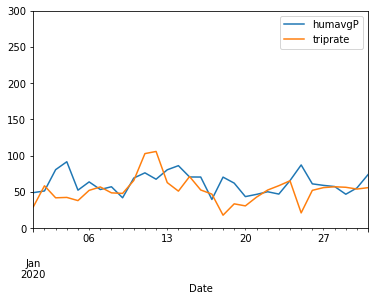

In [ ]:
# fig,ax=plt.subplots(figsize=(7,5))
# ax.plot(dff1['Date'], dff1['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff1['Date'], dff1['humavgP'], label='humavgP', color ='tab:red')
# #plt.xlim(Date[d%],31)
# plt.legend(loc = 'best')
# plt.xlabel('Jan 2020')
# plt.show()
# ax = sns.countplot(x='Spring_2020', data=Spring)
# ax.set(ylim=(0, 700000))
plt1.set_index("Date", inplace=True)
plt1.plot()
plt.ylim(0,300)

(0.0, 300.0)

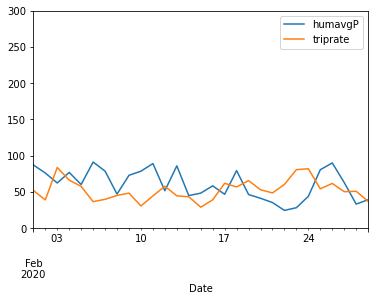

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff2['Date'], dff2['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff2['Date'], dff2['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt2.set_index("Date", inplace=True)
plt2.plot()
plt.ylim(0,300)

(0.0, 300.0)

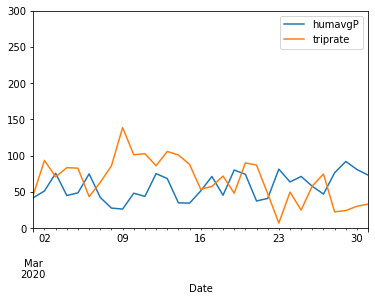

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff3['Date'], dff3['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff3['Date'], dff3['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt3.set_index("Date", inplace=True)
plt3.plot()
plt.ylim(0,300)

(0.0, 300.0)

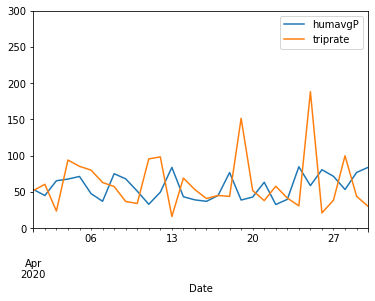

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff4['Date'], dff4['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff4['Date'], dff4['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt4.set_index("Date", inplace=True)
plt4.plot()
plt.ylim(0,300)

(0.0, 300.0)

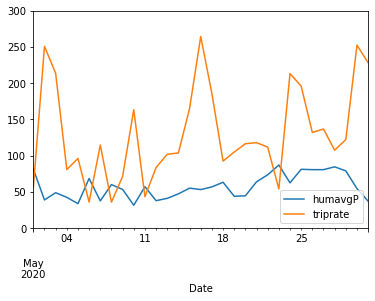

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff5['Date'], dff5['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff5['Date'], dff5['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt5.set_index("Date", inplace=True)
plt5.plot()
plt.ylim(0,300)

(0.0, 300.0)

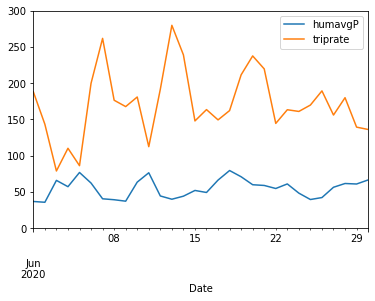

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff6['Date'], dff6['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff6['Date'], dff6['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt6.set_index("Date", inplace=True)
plt6.plot()
plt.ylim(0,300)

(0.0, 300.0)

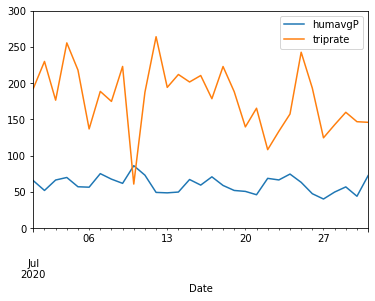

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff7['Date'], dff7['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff7['Date'], dff7['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt7.set_index("Date", inplace=True)
plt7.plot()
plt.ylim(0,300)

(0.0, 300.0)

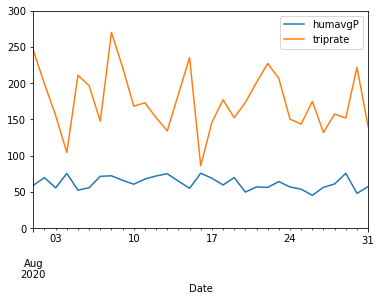

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff8['Date'], dff8['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff8['Date'], dff8['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt8.set_index("Date", inplace=True)
plt8.plot()
plt.ylim(0,300)

(0.0, 300.0)

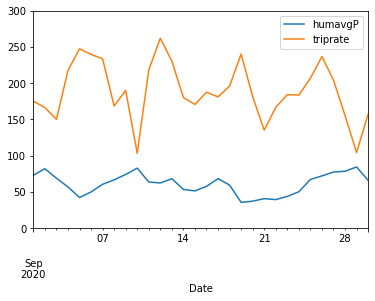

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff9['Date'], dff9['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff9['Date'], dff9['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt9.set_index("Date", inplace=True)
plt9.plot()
plt.ylim(0,300)

(0.0, 300.0)

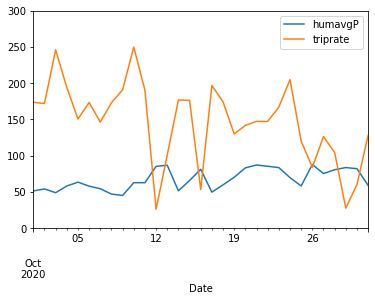

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff10['Date'], dff10['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff10['Date'], dff10['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt10.set_index("Date", inplace=True)
plt10.plot()
plt.ylim(0,300)

(0.0, 300.0)

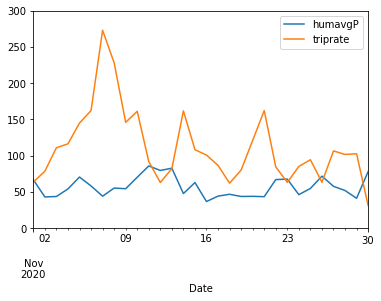

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff11['Date'], dff11['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff11['Date'], dff11['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt11.set_index("Date", inplace=True)
plt11.plot()
plt.ylim(0,300)

(0.0, 300.0)

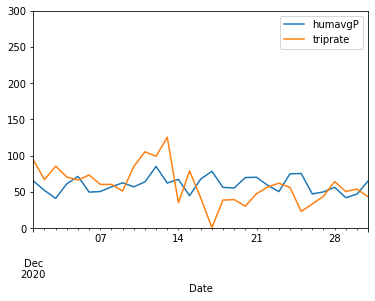

In [ ]:
# fig,ax=plt.subplots()
# ax.plot(dff12['Date'], dff12['triprate'], label='triprate', color ='tab:blue')
# ax.plot(dff12['Date'], dff12['humavgP'], label='humavgP', color ='tab:red')
# plt.legend(loc = 'best')
# plt.show()

plt12.set_index("Date", inplace=True)
plt12.plot()
plt.ylim(0,300)

In [ ]:
JanDecdf=dff1.append(dff2).append(dff3).append(dff4).append(dff5).append(dff6).append(dff7).append(dff8).append(dff9).append(dff10).append(dff11).append(dff12)

In [ ]:
JanDecdf[["humavgP", "triprate"]].corr()

,humavgP,triprate
humavgP,1.000000,-0.164094
triprate,-0.164094,1.000000


In [ ]:
JanDecdf[["humavgP", "triprate"]].cov()

,humavgP,triprate
humavgP,222.214941,-164.951843
triprate,-164.951843,4547.296043


In [ ]:
rh1=dff1[['Date','humavgP']]
rh2=dff2[['Date','humavgP']]
rh3=dff3[['Date','humavgP']]
rh4=dff4[['Date','humavgP']]
rh5=dff5[['Date','humavgP']]
rh6=dff6[['Date','humavgP']]
rh7=dff7[['Date','humavgP']]
rh8=dff8[['Date','humavgP']]
rh9=dff9[['Date','humavgP']]
rh10=dff10[['Date','humavgP']]
rh11=dff11[['Date','humavgP']]
rh12=dff12[['Date','humavgP']]

In [ ]:
#Preparing data for export 
pr1 = pd.merge(pdf1,rh1, how ='left', left_on=['Date'], right_on=['Date'])
pr2 = pd.merge(pdf2,rh2, how ='left', left_on=['Date'], right_on=['Date'])
pr3 = pd.merge(pdf3,rh3, how ='left', left_on=['Date'], right_on=['Date'])
pr4 = pd.merge(pdf4,rh4, how ='left', left_on=['Date'], right_on=['Date'])
pr5 = pd.merge(pdf5,rh5, how ='left', left_on=['Date'], right_on=['Date'])
pr6 = pd.merge(pdf6,rh6, how ='left', left_on=['Date'], right_on=['Date'])
pr7 = pd.merge(pdf7,rh7, how ='left', left_on=['Date'], right_on=['Date'])
pr8 = pd.merge(pdf8,rh8, how ='left', left_on=['Date'], right_on=['Date'])
pr9 = pd.merge(pdf9,rh9, how ='left', left_on=['Date'], right_on=['Date'])
pr10 = pd.merge(pdf10,rh10, how ='left', left_on=['Date'], right_on=['Date'])
pr11 = pd.merge(pdf11,rh11, how ='left', left_on=['Date'], right_on=['Date'])
pr12 = pd.merge(pdf12,rh12, how ='left', left_on=['Date'], right_on=['Date'])

In [ ]:
prd =pr1.append(pr2).append(pr3).append(pr4).append(pr5).append(pr6).append(pr7).append(pr8).append(pr9).append(pr10).append(pr11).append(pr12)

In [ ]:
prd.rename(columns = {"start station name":"start_station_name", "start station latitude":"latitude", "start station longitude":"longitude"}, inplace="True")

In [ ]:
prd["mtrip"]=prd.mtrip/60

In [ ]:
#FOR POWER BI
pbi = prd

In [ ]:
pbi['Month'] = pbi['Date'].dt.strftime('%b-%Y')

In [ ]:
pbi.to_csv('Nafiu Citibike PowerBI', sep='\t')

In [ ]:
pr=prd[['Date','start_station_name', 'mtrip','humavgP']]

In [ ]:
#pr.set_index("Date", inplace=True)

## 7. Station-level time-series forecasting

A selected station is examined using rolling statistics, Augmented Dickey-Fuller stationarity tests, differencing, ACF/PACF analysis, and several forecasting approaches including ARIMA, Auto-ARIMA, SARIMAX, and Prophet.

In [ ]:
pr_df=pr.loc[pr['start_station_name']=='1 Ave & E 68 St']

In [ ]:
pr_df = pr_df.reset_index(drop=True)

In [ ]:
pr_df.set_index("Date", inplace=True)

<AxesSubplot:xlabel='Date'>

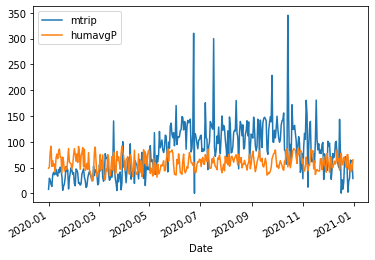

In [ ]:
pr_df.plot()

<AxesSubplot:xlabel='Date'>

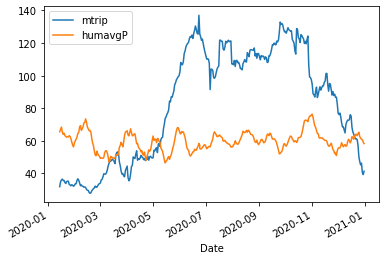

In [ ]:
pr_df_mean = pr_df.rolling(window=14).mean()
pr_df_mean.plot()

In [ ]:
#Checking stationary using ADFULLER
from statsmodels.tsa.stattools import adfuller

In [ ]:
df_test= adfuller(pr_df['humavgP'])

In [ ]:
#HYPOTHESIS
#H0: Not stationary
#H1: Stationary

def adfuller_test(humavgP):
    result = adfuller(humavgP)
    labels = ['ADF Test Statistic', 'p-value', '#Lag used', 'Number of Observations used']
    for value,label in zip(result, labels):
        print(label+' : '+str(value))
    if result[1] <=0.05:
        print("It is Stationary")
    else:
        print("It is not Stationary")

In [ ]:
adfuller_test(pr_df['humavgP'])

ADF Test Statistic : -12.69718734690599
p-value : 1.0996090868141433e-23
#Lag used : 0
Number of Observations used : 366
It is Stationary


In [ ]:
adfuller_test(pr_df['mtrip'])

ADF Test Statistic : -1.3703616640564906
p-value : 0.5963997735190125
#Lag used : 17
Number of Observations used : 349
It is not Stationary


In [ ]:
#DIFFERENCING FOR MTRIP
pr_df['mtrip_stationary'] = pr_df['mtrip'] - pr_df['mtrip'].shift(1)

In [ ]:
adfuller_test(pr_df['mtrip_stationary'].dropna())

ADF Test Statistic : -5.33663242000987
p-value : 4.595776405234017e-06
#Lag used : 16
Number of Observations used : 349
It is Stationary


<AxesSubplot:xlabel='Date'>

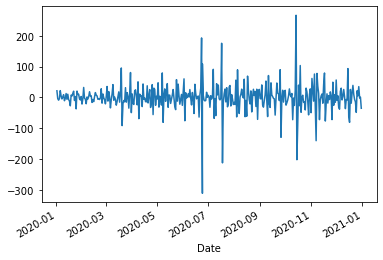

In [ ]:
pr_df['mtrip_stationary'].plot()

<AxesSubplot:xlabel='Date'>

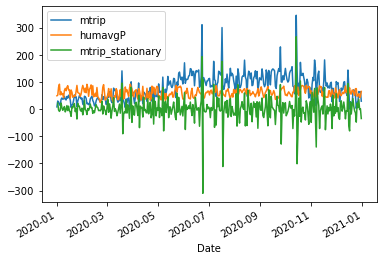

In [ ]:
pr_df.plot()

In [ ]:
#Previous value is the reflection of future values..based line model
#pr_df =pd.concat(pr_df, pr_df.shift(1))

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
#acf for q and pacf for p

In [ ]:
import statsmodels.api as sm
import warnings
import itertools

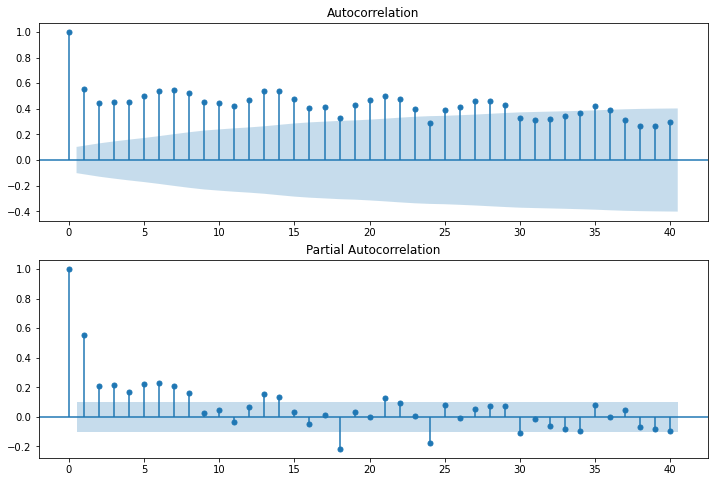

In [ ]:
fig =plt.figure(figsize=(12,8))
ax1 =fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(pr_df['mtrip'].dropna(), lags=40, ax=ax1)
ax2 =fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(pr_df['mtrip'].dropna(), lags=40, ax=ax2)

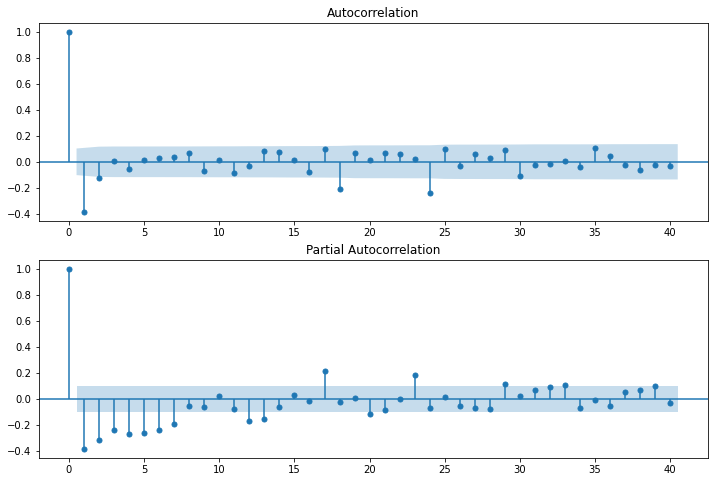

In [ ]:
fig =plt.figure(figsize=(12,8))
ax1 =fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(pr_df['mtrip_stationary'].dropna(), lags=40, ax=ax1)
ax2 =fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(pr_df['mtrip_stationary'].dropna(), lags=40, ax=ax2)

In [ ]:
pr_dfcheck = pr_df[1:]

In [ ]:
pr_dfcheck = pr_dfcheck.reset_index()

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
NaiveRMSE = mean_squared_error(pr_dfcheck['mtrip'], pr_dfcheck['mtrip_stationary'])
np.sqrt(NaiveRMSE)

93.91486211188726

In [ ]:
pr_df = pr_df.reset_index()

In [ ]:
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import ExponentialSmoothing


from pandas import to_datetime

import datetime
from datetime import datetime
warnings.filterwarnings('ignore')

In [ ]:
from fbprophet import Prophet

In [ ]:
import pmdarima as pm
from pmdarima.model_selection import train_test_split

In [ ]:
X_train = pr[pr['Date'] < '2020-11-14']
X_valid = pr[pr['Date'] >= '2020-11-14']

print('X_train shape', X_train.shape)
print('X_valid shape', X_valid.shape)

X_train['Date'].unique()

X_train shape (301554, 4)
X_valid shape (52216, 4)


array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000',
       '2020-01-11T00:00:00.000000000', '2020-01-12T00:00:00.000000000',
       '2020-01-13T00:00:00.000000000', '2020-01-14T00:00:00.000000000',
       '2020-01-15T00:00:00.000000000', '2020-01-16T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-19T00:00:00.000000000', '2020-01-20T00:00:00.000000000',
       '2020-01-21T00:00:00.000000000', '2020-01-22T00:00:00.000000000',
       '2020-01-23T00:00:00.000000000', '2020-01-24T00:00:00.000000000',
       '2020-01-25T00:00:00.000000000', '2020-01-26T00:00:00.000000000',
       '2020-01-27T00:00:00.000000000', '2020-01-28

In [ ]:
#Splitting data 
#train data
station = X_train[X_train['start_station_name'] == '1 Ave & E 68 St']
station2 = station[['Date', 'mtrip']]
#TESTING STATIONS:1 Ave & E 30 St, Pershing Square North, 1 Ave & E 68 St
#valid data
station_va = X_valid[X_valid['start_station_name'] == '1 Ave & E 68 St']
station_va2 = station_va[['Date', 'mtrip']]

#Set index
station2.set_index('Date', inplace=True)
station_va2.set_index('Date', inplace=True)

#Setting index for 48 days
index_48_days = pd.date_range(station2.index[-1], freq='D', periods = 48)

index_48_days 

DatetimeIndex(['2020-11-13', '2020-11-14', '2020-11-15', '2020-11-16',
               '2020-11-17', '2020-11-18', '2020-11-19', '2020-11-20',
               '2020-11-21', '2020-11-22', '2020-11-23', '2020-11-24',
               '2020-11-25', '2020-11-26', '2020-11-27', '2020-11-28',
               '2020-11-29', '2020-11-30', '2020-12-01', '2020-12-02',
               '2020-12-03', '2020-12-04', '2020-12-05', '2020-12-06',
               '2020-12-07', '2020-12-08', '2020-12-09', '2020-12-10',
               '2020-12-11', '2020-12-12', '2020-12-13', '2020-12-14',
               '2020-12-15', '2020-12-16', '2020-12-17', '2020-12-18',
               '2020-12-19', '2020-12-20', '2020-12-21', '2020-12-22',
               '2020-12-23', '2020-12-24', '2020-12-25', '2020-12-26',
               '2020-12-27', '2020-12-28', '2020-12-29', '2020-12-30'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
from math import sqrt

In [ ]:
import itertools
p=d=q=range(0,5)
pdq = list(itertools.product(p,d,q))

for param in pdq:
    try:
        model_arima = ARIMA(station2, order = param)
        model_arima_fit = model_arima.fit()
        print(param, model_arima_fit.aic)
    except:
        continue

#AIC is the Akaike information criteria is an estimator of sample prediction error and thereby relative quality of statistical
#models for a given set of data

(0, 0, 0) 3389.6755338660537
(0, 0, 1) 3314.946800933362
(0, 0, 2) 3296.6518068087066
(0, 0, 3) 3282.008203314594
(0, 0, 4) 3278.4849401427887
(0, 1, 0) 3340.3623521186873
(0, 1, 1) 3171.913416097519
(0, 1, 2) 3172.148844745927
(0, 1, 3) 3168.628148564495
(0, 1, 4) 3166.1256712352497
(0, 2, 0) 3657.213656035767
(0, 2, 1) 3338.5931040798387
(0, 2, 2) 3173.4342907951877
(0, 2, 3) 3173.6594410245953
(0, 2, 4) 3170.1955214992777
(1, 0, 0) 3273.587558015001
(1, 0, 1) 3184.4465344592104
(1, 1, 0) 3286.9979148614057
(1, 2, 0) 3516.4225453687914
(1, 2, 4) 3166.740898102108
(2, 0, 0) 3258.395568782524
(2, 1, 0) 3253.9658377884853
(2, 1, 1) 3169.288731929969
(2, 2, 0) 3436.5425726467956
(2, 2, 4) 3173.6105327424893
(3, 0, 0) 3243.2180621199213
(3, 0, 1) 3181.774038507203
(3, 1, 0) 3237.197572961145
(3, 1, 1) 3167.8617036097194
(3, 1, 3) 3142.1991206237108
(3, 1, 4) 3138.7120136216663
(3, 2, 0) 3399.1761468338364
(3, 2, 4) 3164.851097408983
(4, 0, 0) 3234.5659341287583
(4, 0, 1) 3180.241763698763

45.40803546810345

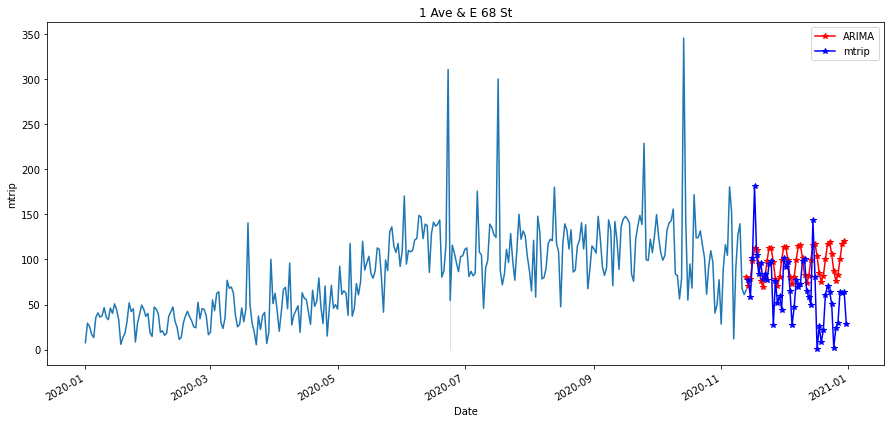

In [ ]:
#Running ARIMA
model_arima = ARIMA(station2, order=(4,1,3))
model_arima_fit = model_arima.fit(disp=-1)

#SAVING ARIMA Prediction
predict1 = model_arima_fit.forecast(48)[0]

#Passing the same index as others
predict1 = pd.Series(predict1, index=index_48_days)
predict1 = predict1.rename("ARIMA")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='mtrip', data=station)
chart.set_title('1 Ave & E 68 St')
predict1.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ARIMAMSE = np.square(np.subtract(predict1.values, station_va['mtrip'].values)).mean()
np.sqrt(ARIMAMSE)

In [ ]:
model_arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             ARIMA Model Results                              
==============================================================================
Dep. Variable:                D.mtrip   No. Observations:                  318
Model:                 ARIMA(4, 1, 3)   Log Likelihood               -1570.786
Method:                       css-mle   S.D. of innovations        8215122.844
Date:                Sat, 10 Jul 2021   AIC                           3159.572
Time:                        03:50:43   BIC                           3193.430
Sample:                             1   HQIC                          3173.095
                                                                              
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1934        nan        nan        nan         nan         nan
ar.L1.D.mtrip     1.2054        nan        nan        nan         nan         nan
ar.L2.D.mtrip    -1.0434        nan        nan        nan         nan         nan
ar.L3.D.mtrip     0.0843   9.71e-07   8.68e+04      0.000       0.084       0.084
ar.L4.D.mtrip    -0.1078      1e-06  -1.07e+05      0.000      -0.108      -0.108
ma.L1.D.mtrip    -2.1340      0.028    -77.154      0.000      -2.188      -2.080
ma.L2.D.mtrip     2.0748      0.046     44.686      0.000       1.984       2.166
ma.L3.D.mtrip    -0.8474      0.039    -21.586      0.000      -0.924      -0.770
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.6283           -0.7780j            1.0000           -0.1419
AR.2            0.6283           +0.7780j            1.0000            0.1419
AR.3           -0.2377           -3.0357j            3.0450           -0.2624
AR.4           -0.2377           +3.0357j            3.0450            0.2624
MA.1            0.6485           -0.7774j            1.0124           -0.1394
MA.2            0.6485           +0.7774j            1.0124            0.1394
MA.3            1.1514           -0.0000j            1.1514           -0.0000
-----------------------------------------------------------------------------
"""

In [ ]:
sarimax_model = SARIMAX(pr_dfcheck['mtrip'], order=(2,1,1), seasonal_order=(1,1,1,4), exog=pr_dfcheck['humavgP'])

In [ ]:
res=sarimax_model.fit(disp=False)

In [ ]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                             mtrip   No. Observations:                  366
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 4)   Log Likelihood               -1794.642
Date:                           Sat, 10 Jul 2021   AIC                           3603.283
Time:                                   04:20:46   BIC                           3630.505
Sample:                                        0   HQIC                          3614.106
                                           - 366                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
humavgP       -0.3404      0.133     -2.550      0.011      -0.602      -0.079
ar.L1          0.0640      0.052      1.222      0.222      -0.039       0.167
ar.L2         -0.1578      0.057     -2.771      0.006      -0.269      -0.046
ma.L1         -0.8634      0.046    -18.881      0.000      -0.953      -0.774
ar.S.L4       -0.1312      0.059     -2.215      0.027      -0.247      -0.015
ma.S.L4       -0.9915      0.063    -15.728      0.000      -1.115      -0.868
sigma2      1153.6423     68.380     16.871      0.000    1019.621    1287.664
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):              2150.54
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               4.08   Skew:                             1.57
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

33.131266171412335

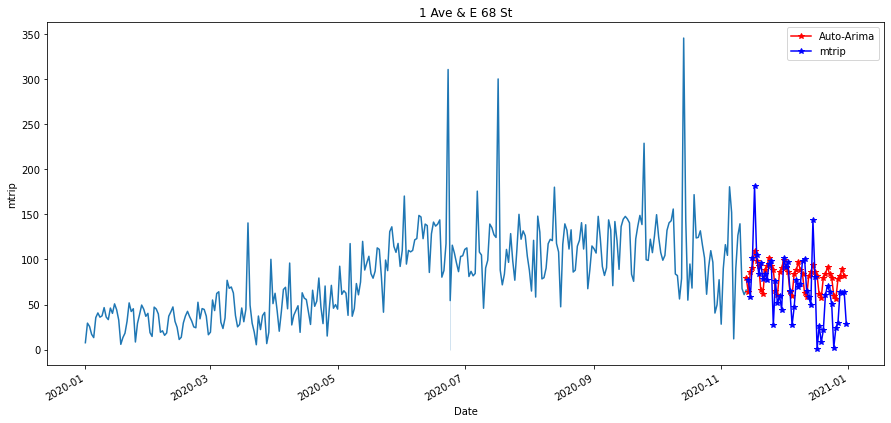

In [ ]:
#AUTO ARIMA
auto_arima_model = pm.auto_arima(station2, seasonal=True, m=7)

#m=7 for daily, 12 for monthly, 52 for weekly data

predict2 = auto_arima_model.predict(48)
predict2 = pd.Series(predict2, index=index_48_days)
predict2 = predict2.rename("Auto-Arima")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='mtrip', data=station)
chart.set_title('1 Ave & E 68 St')
predict2.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

AUTOARIMAMSE = np.square(np.subtract(predict2.values, station_va['mtrip'].values)).mean()
np.sqrt(AUTOARIMAMSE)

In [ ]:
auto_arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  319
Model:             SARIMAX(2, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood               -1566.542
Date:                                Sat, 10 Jul 2021   AIC                           3147.083
Time:                                        00:12:14   BIC                           3173.417
Sample:                                             0   HQIC                          3157.601
                                                - 319                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0386      0.050     -0.767      0.443      -0.137       0.060
ar.L2         -0.1401      0.053     -2.633      0.008      -0.244      -0.036
ma.L1         -0.8751      0.036    -24.644      0.000      -0.945      -0.806
ar.S.L7        0.9615      0.042     23.119      0.000       0.880       1.043
ma.S.L7       -0.9626      0.076    -12.591      0.000      -1.112      -0.813
ma.S.L14       0.0953      0.072      1.326      0.185      -0.046       0.236
sigma2      1095.9071     42.136     26.009      0.000    1013.323    1178.492
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              1982.10
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               4.07   Skew:                             1.65
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


58.34331144199213

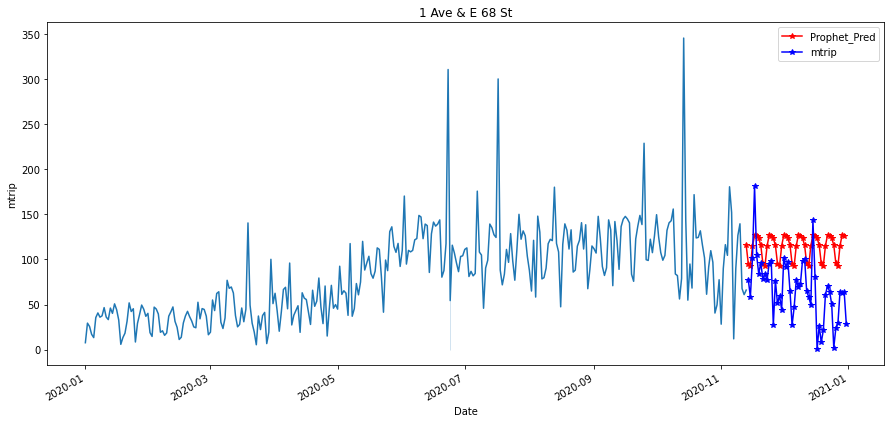

In [ ]:
station3 = station.copy()
station3 = station3[['Date', 'mtrip']]
station3.columns = ['ds', 'y']
station3['ds'] = to_datetime(station3['ds'])

#Model
model = Prophet()
#fitting
prophet_model = model.fit(station3)

#define the prediction period
df_index_48_days = pd.DataFrame(index_48_days)
df_index_48_days.columns = ['ds']
df_index_48_days['ds'] = to_datetime(df_index_48_days['ds'])

#prediction
predict3 = prophet_model.predict(df_index_48_days)
predict3 = pd.Series(predict3['yhat'].values, index=index_48_days)
predict3 = predict3.rename("Prophet_Pred")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='mtrip', data=station)
chart.set_title('1 Ave & E 68 St')
predict3.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ProphetMSE = np.square(np.subtract(predict3.values, station_va['mtrip'].values)).mean()
np.sqrt(ProphetMSE)
yearly_seasonality=True
#prophet_plot_components(model, predict3)

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


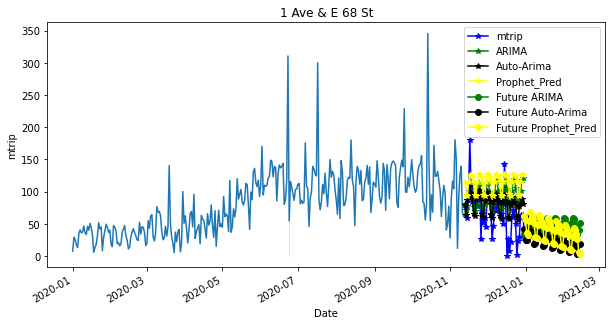

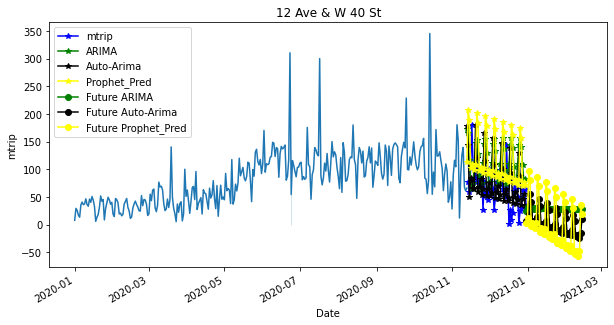

In [ ]:
stations = pr['start_station_name'].unique()

Stations = ['1 Ave & E 68 St','12 Ave & W 40 St'] 
#Stations = ['Metropolitan Ave & Meeker Ave'] 

for c in Stations:
    #filter train data
    train_data = X_train[X_train['start_station_name'] == c]
    train_data2 = train_data[['Date', 'mtrip']]
    
    #filter valid data
    valid_data = X_valid[X_valid['start_station_name'] == c]
    valid_data2 = valid_data[['Date', 'mtrip']]
    
    #all the data from the beginning
    all_data = pr[pr['start_station_name'] == c]
    all_data2 = all_data[['Date', 'mtrip']]
    
    #convert to datetime
    train_data2.set_index('Date', inplace=True)
    valid_data2.set_index('Date', inplace=True)
    valid_data2.columns = ['Validated Data']
    all_data2.set_index('Date', inplace=True)
    
    #setting the validation days
    index_48_days = pd.date_range(train_data2.index[-1], freq='D', periods = 48)
    
    #Setting the future days
    future_index_46_days = pd.date_range(valid_data2.index[-1], freq='D', periods = 46)
    
    try:
        del t_predict1
        del t_predict2
        del t_predict3
        
        del f_predict1
        del f_predict2
        del f_predict3
        
    except:
        print("")
        
        
    #VALID ARIMA
    try:
        try:
            model_arima = ARIMA(train_data2, order=(4,1,3))
            model_arima_fit = model_arima.fit(disp=-1)

            #SAVING ARIMA Prediction
            t_predict1 = model_arima_fit.forecast(48)[0]

            #Passing the same index as others
            t_predict1 = pd.Series(t_predict1, index=index_48_days)
            t_predict1 = t_predict1.rename("ARIMA")
        except:
            model_arima = ARIMA(train_data2, order=(4,1,4))
            model_arima_fit = model_arima.fit(disp=-1)

            #SAVING ARIMA Prediction
            t_predict1 = model_arima_fit.forecast(48)[0]

            #Passing the same index as others
            t_predict1 = pd.Series(t_predict1, index=index_48_days)
            t_predict1 = t_predict1.rename("ARIMA")
    except:
        print(c, 'Arima Error')
        
    #FUTURE ARIMA
    try:
        try:
            model_arima = ARIMA(all_data2, order=(4,1,3))
            model_arima_fit = model_arima.fit(disp=-1)

            #SAVING ARIMA Prediction
            f_predict1 = model_arima_fit.forecast(46)[0]

            #Passing the same index as others
            f_predict1 = pd.Series(f_predict1, index=future_index_46_days)
            f_predict1 = f_predict1.rename("Future ARIMA")
        except:
            model_arima = ARIMA(all_data2, order=(4,1,4))
            model_arima_fit = model_arima.fit(disp=-1)

            #SAVING ARIMA Prediction
            f_predict1 = model_arima_fit.forecast(46)[0]

            #Passing the same index as others
            f_predict1 = pd.Series(f_predict1, future_index_46_days)
            f_predict1 = f_predict1.rename("Future ARIMA")
    except:
        print(c, 'Arima Future Error')
    
    #AUTO ARIMA VALIDATED
    try:
        auto_arima_model = pm.auto_arima(train_data2, seasonal=True, m=7)

        #m=7 for daily, 12 for monthly, 52 for weekly data

        t_predict2 = auto_arima_model.predict(48)
        t_predict2 = pd.Series(t_predict2, index=index_48_days)
        t_predict2 = t_predict2.rename("Auto-Arima")
    except:
        print(c, 'Auto Arima Error')
    
    #AUTO ARIMA FUTURE
    try:
        auto_arima_model = pm.auto_arima(all_data2, seasonal=True, m=7)

        #m=7 for daily, 12 for monthly, 52 for weekly data

        f_predict2 = auto_arima_model.predict(46)
        f_predict2 = pd.Series(f_predict2, index=future_index_46_days)
        f_predict2 = f_predict2.rename("Future Auto-Arima")
    except:
        print(c, 'Future Auto Arima Error')
    
    #PROPHET 
    train_data3 = train_data.copy()
    train_data3 = train_data3[['Date', 'mtrip']]
    train_data3.columns = ['ds', 'y']
    train_data3['ds'] = to_datetime(train_data3['ds'])
    
    all_data3 = all_data.copy()
    all_data3 = all_data3[['Date', 'mtrip']]
    all_data3.columns = ['ds', 'y']
    all_data3['ds'] = to_datetime(all_data3['ds'])
    
    #Validated prophet
    val_df_index_48_days = pd.DataFrame(index_48_days)
    val_df_index_48_days.columns = ['ds']
    val_df_index_48_days['ds'] = to_datetime(val_df_index_48_days['ds'])
    
    #Future Prophet
    fu_df_index_46_days = pd.DataFrame(future_index_46_days)
    fu_df_index_46_days.columns = ['ds']
    fu_df_index_46_days['ds'] = to_datetime(fu_df_index_46_days['ds'])

    #Model
    model = Prophet()
    #fitting
    model.fit(train_data3)

    #Validated prophet prediction
    t_predict3 = model.predict(val_df_index_48_days)
    t_predict3 = pd.Series(t_predict3['yhat'].values, index=index_48_days)
    t_predict3 = t_predict3.rename("Prophet_Pred")

    model2 = Prophet()
    #fitting
    model2.fit(all_data3)
    
    #Future prophet prediction
    f_predict3 = model2.predict(fu_df_index_46_days)
    f_predict3 = pd.Series(f_predict3['yhat'].values, index=future_index_46_days)
    f_predict3 = f_predict3.rename("Future Prophet_Pred")
    
    #Plotting
    fig, ax = plt.subplots(figsize=(10,5))
    chart = sns.lineplot(x='Date', y='mtrip', data=station)
    chart.set_title(c)
    station_va2.plot(ax=ax, color='blue', marker='*', legend=True)
    
    try:
        t_predict1.plot(ax=ax, color='green', marker='*', legend=True)
    except:
        print("")
    try:
        t_predict2.plot(ax=ax, color='black', marker='*', legend=True)
    except:
        print("")
    try:
        t_predict3.plot(ax=ax, color='Yellow', marker='*', legend=True)
    except:
        print("")
        
    try:
        f_predict1.plot(ax=ax, color='green', marker='o', legend=True)
    except:
        print("")
    try:
        f_predict2.plot(ax=ax, color='black', marker='o', legend=True)
    except:
        print("") 
    try:
        f_predict3.plot(ax=ax, color='Yellow', marker='o', legend=True)
    except:
        print("")

## 8. Operational inspection analytics

Bike-share inspection records are analyzed to examine operational conditions and internal/external factors relevant to bike-sharing disposition.

In [ ]:
insp=pd.read_csv('Bike_Share_Inspections.csv')

In [ ]:
insp=pd.read_csv('Bike_Share_Inspections.csv')
insp['InpectionDate'] = pd.to_datetime(insp['InpectionDate'])

In [ ]:
insp['Year'] = insp['InpectionDate'].dt.strftime('%Y')

In [ ]:
inspect=insp.loc[insp['Year']=='2020']

In [ ]:
inspect['Month'] = inspect['InpectionDate'].dt.strftime('%Y-%m')

In [ ]:
#How many times they carried out inspection? between Jan and March
inspect['Location'].value_counts().sum()

2878

In [ ]:
#Most inspected location/station
inspect['Location'].value_counts()

West 31st Street and Seventh Avenue       7
Bank Street and Washington Street         6
Eleventh Avenue and West 41st Street      6
Eighth Avenue and West 31st Street        6
Sixth Avenue and West 32nd Street         6
                                         ..
Suydam Street and Knickerbocker Avenue    1
Driggs Avenue and North 9th Street        1
Henry Street and Columbia Street          1
Knickerbocker Avenue and George Street    1
Pearl Street and Anchorage Place          1
Name: Location, Length: 788, dtype: int64

In [ ]:
#CATEGORY A
#1. Are station and bikes completely free of all inspection issues? = Question1 = Case1
#2. Is the station clean and free of external defects? = Question2 = Case2
#3. Is any bike unclean or visibly defective? = Question8 = Case3

#CATEGORY B
#1. How many docks are disabled at this station? = Question6 = Case4
#2. How many available bikes are at a station? = Question9 = Case5
#3. How many available docks are at this station? = Question10 = Case6

In [ ]:
#RENAMING OF COLUMNS
inspect.rename(columns = {"Question1":"Case1", "Question2":"Case2", "Question8":"Case3", "Question6":"Case4", "Question9":"Case5", "Question10":"Case6"}, inplace="True")

In [ ]:
inspect=inspect[['Month','Case1', 'Case2', 'Case3', 'Case4', 'Case5', 'Case6']]

In [ ]:
inspect.sum(axis=0) 

Month    2020-012020-012020-022020-012020-022020-012020...
Case1    YesYesYesNoNoYesYesNoYesNoYesNoYesYesYesNoYesN...
Case2    YesYesYesYesNoYesYesYesYesNoYesNoYesYesYesNoYe...
Case4                                                  0.0
Case5                                                  0.0
Case6                                                  0.0
dtype: object

In [ ]:
#CATEGORY A
#Case 1: Are station and bikes completely free of all inspection issues? = Question1
inspect['Case1'].value_counts()

Yes    2240
No      638
Name: Case1, dtype: int64

[(0.0, 2900.0)]

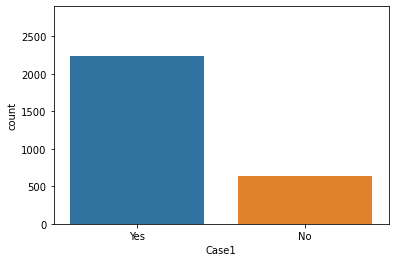

In [ ]:
ax = sns.countplot(inspect['Case1'])
ax.set(ylim=(0, 2900))

In [ ]:
#CATEGORY A
#Case 2: Is the station clean and free of external defects? = Question2
inspect['Case2'].value_counts()

Yes    2710
No      168
Name: Case2, dtype: int64

[(0.0, 2900.0)]

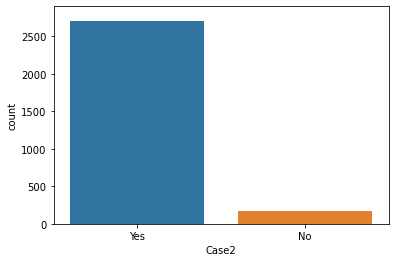

In [ ]:
ax = sns.countplot(inspect['Case2'])
ax.set(ylim=(0, 2900))

In [ ]:
#CATEGORY A
#Case 3: Is any bike unclean or visibly defective? = Question8
inspect['Case3'].value_counts()

No    2841
Name: Case3, dtype: int64

[(0.0, 2900.0)]

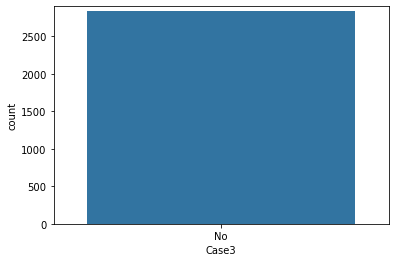

In [ ]:
ax = sns.countplot(inspect['Case3'])
ax.set(ylim=(0, 2900))

In [ ]:
view_inspect = inspect[["Month","Case4","Case5","Case6"]]

In [ ]:
inspection = view_inspect.replace(np.NaN, 0)

In [ ]:
check_insp= inspection.groupby(['Month'])['Case4', 'Case5', 'Case6'].agg('sum').reset_index()

## 9. Monthly bike-demand forecasting

Monthly demand is aggregated and used for short-horizon forecasting experiments.

In [ ]:
cpd['Month'] = cpd['Date'].dt.strftime('%Y-%m')

In [ ]:
Bike_Demand = cpd[["Month", "demand"]]

In [ ]:
Bike_Demand= Bike_Demand.groupby(['Month'])['demand'].sum().to_frame(name = 'demand').reset_index()

In [ ]:
Bike_Demand['Month'] = pd.to_datetime(Bike_Demand['Month'])

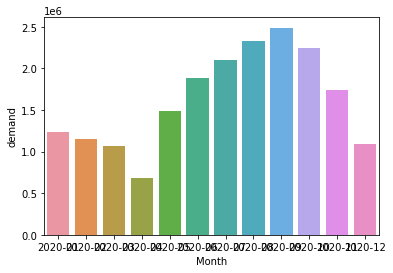

In [ ]:
ax = sns.barplot(data = Bike_Demand, x = 'Month', y = 'demand')

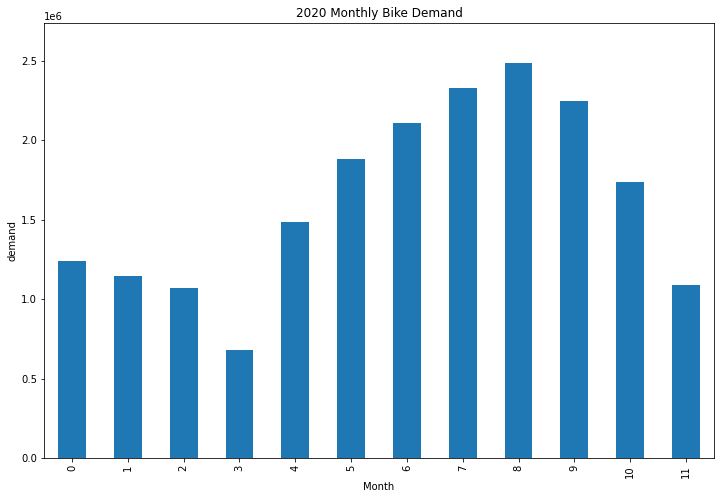

In [ ]:
ax = Bike_Demand.plot(kind='bar', figsize=(12, 8), title='2020 Monthly Bike Demand',
             xlabel='Month', ylabel='demand', legend=False)

# annotate
#ax.bar_label(ax.containers[1], label_type='edge')

# pad the spacing between the number and the edge of the figure
ax.margins(y=0.1)

In [ ]:
Tech_field=pd.read_csv('citibike_Tech.csv')

In [ ]:
Tech_field['Date'] = pd.to_datetime(Tech_field['Date'])

In [ ]:
Tech_field['Month'] = Tech_field['Date'].dt.strftime('%b-%Y')

In [ ]:
Tech_Team = Tech_field[["Month","Visited_stations","Mal_Stations","Expected_Stations","Active_Stations","Mal_Docks","Vandalised"]]

In [ ]:
Tech_Team.to_csv("Tech_Team.csv")

In [ ]:
X_train = Bike_Demand[Bike_Demand['Month'] < '2020-10-01']
X_valid = Bike_Demand[Bike_Demand['Month'] >= '2020-10-01']

print('X_train shape', X_train.shape)
print('X_valid shape', X_valid.shape)

X_train['Month'].unique()

X_train shape (9, 2)
X_valid shape (3, 2)


array(['2020-01-01T00:00:00.000000000', '2020-02-01T00:00:00.000000000',
       '2020-03-01T00:00:00.000000000', '2020-04-01T00:00:00.000000000',
       '2020-05-01T00:00:00.000000000', '2020-06-01T00:00:00.000000000',
       '2020-07-01T00:00:00.000000000', '2020-08-01T00:00:00.000000000',
       '2020-09-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [ ]:
#Splitting data 
#train data
#station = X_train[X_train['start_station_name'] == '1 Ave & E 68 St']
station2 = X_train[['Month', 'demand']]
#TESTING STATIONS:1 Ave & E 30 St, Pershing Square North, 1 Ave & E 68 St
#valid data
#station_va = X_valid[X_valid['start_station_name'] == '1 Ave & E 68 St']
station_va2 = X_valid[['Month', 'demand']]

#Set index
station2.set_index('Month', inplace=True)
station_va2.set_index('Month', inplace=True)

#Setting index for 48 days
index_3_months = pd.date_range(station2.index[-1], freq='M', periods = 3)

index_3_months

DatetimeIndex(['2020-09-30', '2020-10-31', '2020-11-30'], dtype='datetime64[ns]', freq='M')

743548.7341340852

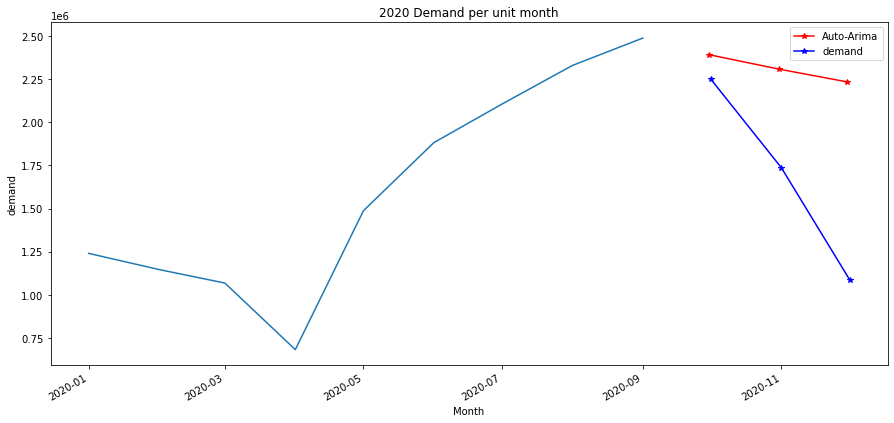

In [ ]:
#AUTO ARIMA
auto_arima_model = pm.auto_arima(station2, seasonal=False, m=12)

#m=7 for daily, 12 for monthly, 52 for weekly data

predict2 = auto_arima_model.predict(3)
predict2 = pd.Series(predict2, index=index_3_months)
predict2 = predict2.rename("Auto-Arima")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Month', y='demand', data=station2)
chart.set_title('2020 Demand per unit month')
predict2.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

AUTOARIMAMSE = np.square(np.subtract(predict2.values, station_va2['demand'].values)).mean()
np.sqrt(AUTOARIMAMSE)

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:fbprophet:n_changepoints greater than number of observations. Using 6.


1262922.9890573877

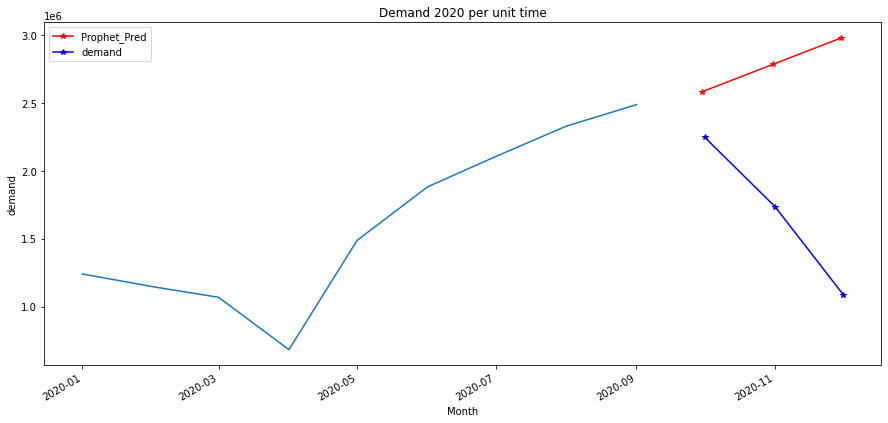

In [ ]:
station3 = X_train.copy()
#station3 = station3.reset_index(drop=False, inplace=True)
station3 = station3[['Month', 'demand']]
station3.columns = ['ds', 'y']
station3['ds'] = to_datetime(station3['ds'])

#Model
model = Prophet()
#fitting
prophet_model = model.fit(station3)

#define the prediction period
df_index_48_days = pd.DataFrame(index_3_months)
df_index_48_days.columns = ['ds']
df_index_48_days['ds'] = to_datetime(df_index_48_days['ds'])

#prediction
predict3 = prophet_model.predict(df_index_48_days)
predict3 = pd.Series(predict3['yhat'].values, index=index_3_months)
predict3 = predict3.rename("Prophet_Pred")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Month', y='demand', data=station2)
chart.set_title('Demand 2020 per unit time')
predict3.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ProphetMSE = np.square(np.subtract(predict3.values, station_va2['demand'].values)).mean()
np.sqrt(ProphetMSE)

## 10. Overall daily usage forecasting

The final section models overall daily bike-usage hours and compares forecasting approaches for future usage expectations.

In [ ]:
overalldf=pd1.append(pd2).append(pd3).append(pd4).append(pd5).append(pd6).append(pd7).append(pd8).append(pd9).append(pd10).append(pd11).append(pd12)

In [ ]:
overalldf['mtrip'] = overalldf.mtrip/60

In [ ]:
overalldf.rename(columns = {"usage_per_hour":"usage_hour"}, inplace="True")

In [ ]:
X_train = overalldf[overalldf['Date'] < '2020-11-14']
X_valid = overalldf[overalldf['Date'] >= '2020-11-14']

print('X_train shape', X_train.shape)
print('X_valid shape', X_valid.shape)

X_train['Date'].unique()

X_train shape (318, 2)
X_valid shape (48, 2)


array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-04T00:00:00.000000000',
       '2020-01-05T00:00:00.000000000', '2020-01-06T00:00:00.000000000',
       '2020-01-07T00:00:00.000000000', '2020-01-08T00:00:00.000000000',
       '2020-01-09T00:00:00.000000000', '2020-01-10T00:00:00.000000000',
       '2020-01-11T00:00:00.000000000', '2020-01-12T00:00:00.000000000',
       '2020-01-13T00:00:00.000000000', '2020-01-14T00:00:00.000000000',
       '2020-01-15T00:00:00.000000000', '2020-01-16T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-19T00:00:00.000000000', '2020-01-20T00:00:00.000000000',
       '2020-01-21T00:00:00.000000000', '2020-01-22T00:00:00.000000000',
       '2020-01-23T00:00:00.000000000', '2020-01-24T00:00:00.000000000',
       '2020-01-25T00:00:00.000000000', '2020-01-26T00:00:00.000000000',
       '2020-01-27T00:00:00.000000000', '2020-01-28

In [ ]:
#Splitting data 
#train data
#station = X_train[X_train['start_station_name'] == '1 Ave & E 68 St']
station2 = X_train[['Date', 'usage_hour']]
#TESTING STATIONS:1 Ave & E 30 St, Pershing Square North, 1 Ave & E 68 St
#valid data
#station_va = X_valid[X_valid['start_station_name'] == '1 Ave & E 68 St']
station_va2 = X_valid[['Date', 'usage_hour']]

#Set index
station2.set_index('Date', inplace=True)
station_va2.set_index('Date', inplace=True)

#Setting index for 48 days
index_48_days = pd.date_range(station2.index[-1], freq='D', periods = 48)

index_48_days

DatetimeIndex(['2020-11-13', '2020-11-14', '2020-11-15', '2020-11-16',
               '2020-11-17', '2020-11-18', '2020-11-19', '2020-11-20',
               '2020-11-21', '2020-11-22', '2020-11-23', '2020-11-24',
               '2020-11-25', '2020-11-26', '2020-11-27', '2020-11-28',
               '2020-11-29', '2020-11-30', '2020-12-01', '2020-12-02',
               '2020-12-03', '2020-12-04', '2020-12-05', '2020-12-06',
               '2020-12-07', '2020-12-08', '2020-12-09', '2020-12-10',
               '2020-12-11', '2020-12-12', '2020-12-13', '2020-12-14',
               '2020-12-15', '2020-12-16', '2020-12-17', '2020-12-18',
               '2020-12-19', '2020-12-20', '2020-12-21', '2020-12-22',
               '2020-12-23', '2020-12-24', '2020-12-25', '2020-12-26',
               '2020-12-27', '2020-12-28', '2020-12-29', '2020-12-30'],
              dtype='datetime64[ns]', freq='D')

8539.43810891557

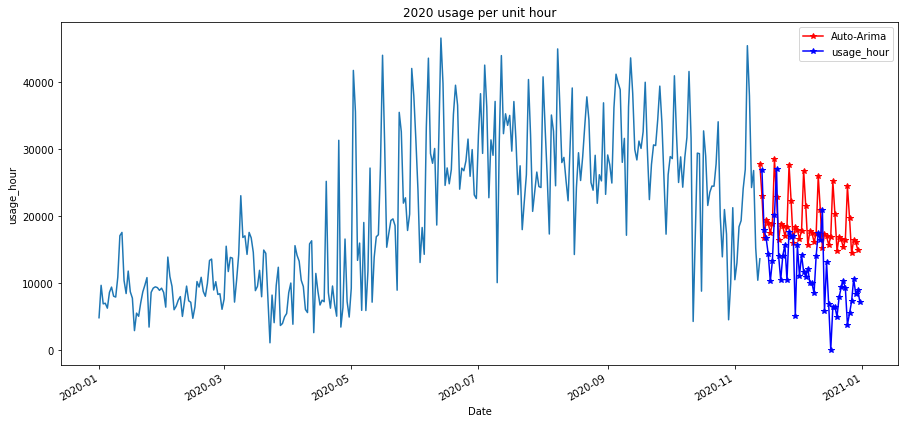

In [ ]:
#AUTO ARIMA
auto_arima_model = pm.auto_arima(station2, seasonal=True, m=7)

#m=7 for daily, 12 for monthly, 52 for weekly data

predict2 = auto_arima_model.predict(48)
predict2 = pd.Series(predict2, index=index_48_days)
predict2 = predict2.rename("Auto-Arima")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='usage_hour', data=station2)
chart.set_title('2020 usage per unit hour')
predict2.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

AUTOARIMAMSE = np.square(np.subtract(predict2.values, station_va2['usage_hour'].values)).mean()
np.sqrt(AUTOARIMAMSE)

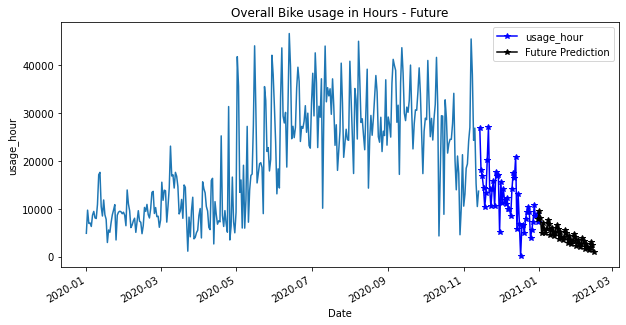

In [ ]:
# stations = pr['start_station_name'].unique()

# Stations = ['1 Ave & E 68 St','12 Ave & W 40 St'] 
# #Stations = ['Metropolitan Ave & Meeker Ave'] 

# for c in Stations:
    #filter train data
#     train_data = X_train[X_train['start_station_name'] == c]
#train_data2 = X_train[['Date', 'usage_per_hour']]
    
    #filter valid data
#     valid_data = X_valid[X_valid['start_station_name'] == c]
#valid_data2 = X_valid[['Date', 'usage_per_hour']]
    
    #all the data from the beginning
#     all_data = pr[pr['start_station_name'] == c]
all_data2 = overalldf[['Date', 'usage_hour']]
    
    #convert to datetime
#train_data2.set_index('Date', inplace=True)
#valid_data2.set_index('Date', inplace=True)
#valid_data2.columns = ['Validated Data']
all_data2.set_index('Date', inplace=True)
    
    #setting the validation days
#index_48_days = pd.date_range(train_data2.index[-1], freq='D', periods = 48)
    
    #Setting the future days
future_index_46_days = pd.date_range(valid_data2.index[-1], freq='D', periods = 46)
    
try:
        #del t_predict1
    #del t_predict2
        #del t_predict3
        
        #del f_predict1
    del f_predict2
        #del f_predict3
        
except:
    print("")
        
#     try:
#         del df_predict1
#         del df_predict2
#     except:
#         print("")
        
    #VALID ARIMA
#     try:
#         try:
#             model_arima = ARIMA(train_data2, order=(4,1,3))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             t_predict1 = model_arima_fit.forecast(48)[0]

#             #Passing the same index as others
#             t_predict1 = pd.Series(t_predict1, index=index_48_days)
#             t_predict1 = t_predict1.rename("ARIMA")
#         except:
#             model_arima = ARIMA(train_data2, order=(4,1,4))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             t_predict1 = model_arima_fit.forecast(48)[0]

#             #Passing the same index as others
#             t_predict1 = pd.Series(t_predict1, index=index_48_days)
#             t_predict1 = t_predict1.rename("ARIMA")
#     except:
#         print(c, 'Arima Error')
        
#     #FUTURE ARIMA
#     try:
#         try:
#             model_arima = ARIMA(all_data2, order=(4,1,3))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             f_predict1 = model_arima_fit.forecast(46)[0]

#             #Passing the same index as others
#             f_predict1 = pd.Series(f_predict1, index=future_index_46_days)
#             f_predict1 = f_predict1.rename("Future ARIMA")
#         except:
#             model_arima = ARIMA(all_data2, order=(4,1,4))
#             model_arima_fit = model_arima.fit(disp=-1)

#             #SAVING ARIMA Prediction
#             f_predict1 = model_arima_fit.forecast(46)[0]

#             #Passing the same index as others
#             f_predict1 = pd.Series(f_predict1, future_index_46_days)
#             f_predict1 = f_predict1.rename("Future ARIMA")
#     except:
#         print(c, 'Arima Future Error')
    
    #AUTO ARIMA VALIDATED
# try:
#     auto_arima_model = pm.auto_arima(train_data2, seasonal=True, m=7)

#         #m=7 for daily, 12 for monthly, 52 for weekly data

#     t_predict2 = auto_arima_model.predict(48)
#     t_predict2 = pd.Series(t_predict2, index=index_48_days)
#     t_predict2 = t_predict2.rename("Auto-Arima")
# except:
#     print(c, 'Auto Arima Error')
    
    #AUTO ARIMA FUTURE
try:
    auto_arima_model = pm.auto_arima(all_data2, seasonal=True, m=7)

        #m=7 for daily, 12 for monthly, 52 for weekly data

    f_predict2 = auto_arima_model.predict(46)
    f_predict2 = pd.Series(f_predict2, index=future_index_46_days)
    f_predict2 = f_predict2.rename("Future Prediction")
except:
    print('Future Prediction Error')
    
#     #PROPHET 
#     train_data3 = train_data.copy()
#     train_data3 = train_data3[['Date', 'mtrip']]
#     train_data3.columns = ['ds', 'y']
#     train_data3['ds'] = to_datetime(train_data3['ds'])
    
#     all_data3 = all_data.copy()
#     all_data3 = all_data3[['Date', 'mtrip']]
#     all_data3.columns = ['ds', 'y']
#     all_data3['ds'] = to_datetime(all_data3['ds'])
    
#     #Validated prophet
#     val_df_index_48_days = pd.DataFrame(index_48_days)
#     val_df_index_48_days.columns = ['ds']
#     val_df_index_48_days['ds'] = to_datetime(val_df_index_48_days['ds'])
    
#     #Future Prophet
#     fu_df_index_46_days = pd.DataFrame(future_index_46_days)
#     fu_df_index_46_days.columns = ['ds']
#     fu_df_index_46_days['ds'] = to_datetime(fu_df_index_46_days['ds'])

#     #Model
#     model = Prophet()
#     #fitting
#     model.fit(train_data3)

#     #Validated prophet prediction
#     t_predict3 = model.predict(val_df_index_48_days)
#     t_predict3 = pd.Series(t_predict3['yhat'].values, index=index_48_days)
#     t_predict3 = t_predict3.rename("Prophet_Pred")

#     model2 = Prophet()
#     #fitting
#     model2.fit(all_data3)
    
#     #Future prophet prediction
#     f_predict3 = model2.predict(fu_df_index_46_days)
#     f_predict3 = pd.Series(f_predict3['yhat'].values, index=future_index_46_days)
#     f_predict3 = f_predict3.rename("Future Prophet_Pred")
    
    #Plotting
fig, ax = plt.subplots(figsize=(10,5))
chart = sns.lineplot(x='Date', y='usage_hour', data=station2)
chart.set_title('Overall Bike usage in Hours - Future')
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)
    
#     try:
#         t_predict1.plot(ax=ax, color='green', marker='*', legend=True)
#     except:
#         print("")
# try:
#     t_predict2.plot(ax=ax, color='black', marker='*', legend=True)
# except:
#     print("")
#     try:
#         t_predict3.plot(ax=ax, color='Yellow', marker='*', legend=True)
#     except:
#         print("")
        
#     try:
#         f_predict1.plot(ax=ax, color='green', marker='o', legend=True)
#     except:
#         print("")
try:
    f_predict2.plot(ax=ax, color='black', marker='*', legend=True)
except:
    print("") 
#     try:
#         f_predict3.plot(ax=ax, color='Yellow', marker='o', legend=True)
#     except:
#         print("")

In [ ]:
f_predict2

2020-12-31    7771.912688
2021-01-01    9476.311239
2021-01-02    8103.645779
2021-01-03    4858.986077
2021-01-04    7043.024777
2021-01-05    5749.366910
2021-01-06    4985.157157
2021-01-07    5804.360900
2021-01-08    7600.865686
2021-01-09    6767.630196
2021-01-10    4589.338519
2021-01-11    6063.305224
2021-01-12    5097.507700
2021-01-13    4270.186021
2021-01-14    4999.102965
2021-01-15    6641.764347
2021-01-16    5810.171181
2021-01-17    3675.025029
2021-01-18    5118.540692
2021-01-19    4189.107838
2021-01-20    3435.176596
2021-01-21    4116.990881
2021-01-22    5648.708423
2021-01-23    4882.332778
2021-01-24    2910.947297
2021-01-25    4243.851780
2021-01-26    3383.673219
2021-01-27    2680.306910
2021-01-28    3314.069715
2021-01-29    4737.984583
2021-01-30    4024.428185
2021-01-31    2188.993815
2021-02-01    3429.985306
2021-02-02    2629.357337
2021-02-03    1975.547999
2021-02-04    2564.959187
2021-02-05    3889.395963
2021-02-06    3225.815187
2021-02-07  

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


14572.61619531169

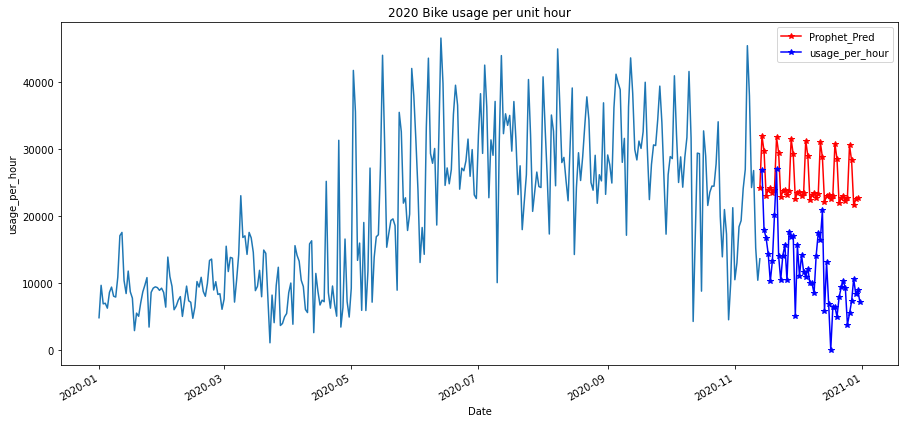

In [ ]:
station3 = X_train.copy()
#station3 = station3.reset_index(drop=False, inplace=True)
station3 = station3[['Date', 'usage_per_hour']]
station3.columns = ['ds', 'y']
station3['ds'] = to_datetime(station3['ds'])

#Model
model = Prophet()
#fitting
prophet_model = model.fit(station3)

#define the prediction period
df_index_48_days = pd.DataFrame(index_48_days)
df_index_48_days.columns = ['ds']
df_index_48_days['ds'] = to_datetime(df_index_48_days['ds'])

#prediction
predict3 = prophet_model.predict(df_index_48_days)
predict3 = pd.Series(predict3['yhat'].values, index=index_48_days)
predict3 = predict3.rename("Prophet_Pred")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='usage_per_hour', data=station2)
chart.set_title('2020 Bike usage per unit hour')
predict3.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ProphetMSE = np.square(np.subtract(predict3.values, station_va2['usage_per_hour'].values)).mean()
np.sqrt(ProphetMSE)

In [ ]:
import itertools
p=d=q=range(0,5)
pdq = list(itertools.product(p,d,q))

for param in pdq:
    try:
        model_arima = ARIMA(station2, order = param)
        model_arima_fit = model_arima.fit()
        print(param, model_arima_fit.aic)
    except:
        continue

#AIC is the Akaike information criteria is an estimator of sample prediction error and thereby relative quality of statistical
#models for a given set of data

(0, 0, 0) 6849.749682507445
(0, 0, 1) 6690.806009552042
(0, 0, 2) 6669.888897171907
(0, 0, 3) 6639.773949459073
(0, 0, 4) 6626.52027956837
(0, 1, 0) 6640.586483319136
(0, 1, 1) 6554.887063583173
(0, 1, 2) 6524.242534569894
(0, 1, 3) 6523.308343847449
(0, 1, 4) 6525.304099128571
(0, 2, 0) 6909.97552255497
(0, 2, 1) 6628.341785137811
(0, 2, 2) 6545.44256205824
(0, 2, 3) 6514.048524798466
(0, 2, 4) 6513.548548742684
(1, 0, 0) 6617.013627178244
(1, 0, 1) 6577.250396094981
(1, 0, 2) 6548.2803592513765
(1, 0, 3) 6545.99479883669
(1, 0, 4) 6548.197287581582
(1, 1, 0) 6622.187345130178
(1, 1, 1) 6533.41331925859
(1, 1, 2) 6522.853515089857
(1, 1, 3) 6523.676729154163
(1, 1, 4) 6521.388972789786
(1, 2, 0) 6825.818182986254
(2, 0, 0) 6613.666579107444
(2, 0, 1) 6556.148940662423
(2, 0, 2) 6546.838577748389
(2, 0, 3) 6547.5949086746205
(2, 0, 4) 6547.943253283771
(2, 1, 0) 6580.101557570131
(2, 1, 1) 6526.007980891537
(2, 1, 2) 6524.314488562427
(2, 1, 3) 6525.190429582734
(2, 1, 4) 6518.25555982

12002.246805751021

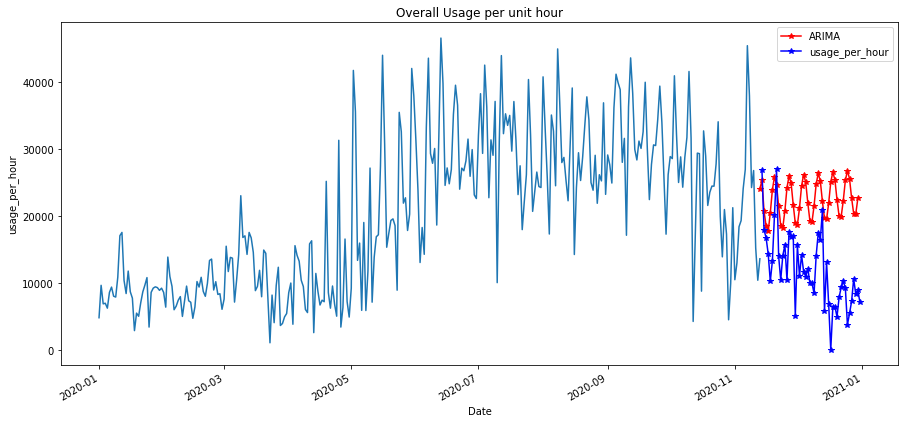

In [ ]:
#Running ARIMA
model_arima = ARIMA(station2, order=(4,1,4))
model_arima_fit = model_arima.fit(disp=-1)

#SAVING ARIMA Prediction
predict1 = model_arima_fit.forecast(48)[0]

#Passing the same index as others
predict1 = pd.Series(predict1, index=index_48_days)
predict1 = predict1.rename("ARIMA")

#Plot Graph
fig, ax = plt.subplots(figsize=(15,7))
chart = sns.lineplot(x='Date', y='usage_per_hour', data=X_train)
chart.set_title('Overall Usage per unit hour')
predict1.plot(ax=ax, color='red', marker='*', legend=True)
station_va2.plot(ax=ax, color='blue', marker='*', legend=True)

ARIMAMSE = np.square(np.subtract(predict1.values, station_va2['usage_per_hour'].values)).mean()
np.sqrt(ARIMAMSE)